# Component Summation

Aggregate projections from the six per-component notebooks into total GMSL.

**Components:** Thermosteric (ocean), Glaciers, Greenland, EAIS, Antarctic Peninsula, WAIS

**Method:** Load MC sample ensembles from `component_results.h5`, sum sample-by-sample to preserve correlations within each draw, then compute percentiles on the total.

**Sections:**
0. Imports & configuration
1. Load all component projections
2. Sum components → total GMSL
3. Summary table (2050, 2100, 2150)
4. Projection fan plots
5. Component stack & variance decomposition
6. IPCC AR6 comparison

In [1]:
import sys, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

plt.style.use('seaborn-v0_8-poster')

sys.path.insert(0, '.')
from component_io import (
    load_all_projections, load_component, list_components,
    PROJ_SSPS, PROJ_YEARS, DEFAULT_H5_PATH,
)
from component_projections import (
    read_ipcc_component_nc, ipcc_extract,
    get_our_stats, get_ipcc_stats, stats_dict,
)
from component_analysis import compute_variance_fractions
from component_plotting import (
    SSP_COLORS, COMP_COLORS, M_TO_MM,
    plot_component_projections,
    plot_variance_decomposition,
)

RAW_DIR = '../data/raw'
FIG_DIR = '../figures'
CONF_BASE = f'{RAW_DIR}/ipcc_ar6/slr/ar6/global/confidence_output_files'

# Display names for components (HDF5 key → label)
# EAIS excluded: IMBIE record too short and noisy to constrain a trend;
# the ~-19 mm contribution is not supported by observations.
COMP_LABELS = {
    'ocean': 'Thermosteric',
    'glacier': 'Glaciers',
    'greenland': 'Greenland',
    # 'eais': 'EAIS',
    'apeninsula': 'Peninsula',
    'wais': 'WAIS',
    'tws': 'TWS',
}

# SSP name → IPCC code
SSP_TO_CODE = {
    'SSP1-2.6': 'ssp126', 'SSP2-4.5': 'ssp245',
    'SSP3-7.0': 'ssp370', 'SSP5-8.5': 'ssp585',
}

## 1. Load All Component Projections

In [2]:
# Inventory
list_components()

File: /Users/minchew/Dropbox/Documents/Research/SLR/forecasting/global_simple_v1/slr_forecast/data/processed/component_results.h5
  Baseline year: 2005.0
  N samples: 2000
  Proj years: 1950–2150

  apeninsula
    model: linear_dols
    SSPs: SSP1-2.6, SSP2-4.5, SSP3-7.0, SSP5-8.5
    full samples: True
    saved: 2026-04-06T22:37:58.031844+00:00
  eais
    model: trend_only
    SSPs: SSP1-2.6, SSP2-4.5, SSP3-7.0, SSP5-8.5
    full samples: True
    saved: 2026-04-06T22:39:06.942984+00:00
  glacier
    model: linear_dols
    SSPs: SSP1-2.6, SSP2-4.5, SSP3-7.0, SSP5-8.5
    full samples: True
    saved: 2026-03-25T03:04:41.065533+00:00
  greenland
    model: smb_literature_plus_discharge_delay
    SSPs: SSP1-2.6, SSP2-4.5, SSP3-7.0, SSP5-8.5
    full samples: True
    saved: 2026-03-27T23:16:05.802670+00:00
  ocean
    model: hybrid_noaa_ipcc
    SSPs: SSP1-2.6, SSP2-4.5, SSP3-7.0, SSP5-8.5
    full samples: True
    saved: 2026-04-06T23:48:15.760157+00:00
  wais
    model: a4_deep_unce

['apeninsula', 'eais', 'glacier', 'greenland', 'ocean', 'wais']

In [3]:
# Load projection ensembles for all components
proj_years, all_proj = load_all_projections()

available = sorted(all_proj.keys())
print(f'Loaded components: {available}')
print(f'Projection years: {proj_years[0]:.0f}–{proj_years[-1]:.0f} ({len(proj_years)} pts)')

# Check SSP coverage per component
for comp in available:
    ssps = sorted(all_proj[comp].keys())
    has_samples = all('samples' in all_proj[comp][s] for s in ssps)
    print(f'  {comp:12s}  SSPs: {", ".join(ssps)}  samples: {has_samples}')

Loaded components: ['apeninsula', 'eais', 'glacier', 'greenland', 'ocean', 'wais']
Projection years: 1950–2150 (201 pts)
  apeninsula    SSPs: SSP1-2.6, SSP2-4.5, SSP3-7.0, SSP5-8.5  samples: True
  eais          SSPs: SSP1-2.6, SSP2-4.5, SSP3-7.0, SSP5-8.5  samples: True
  glacier       SSPs: SSP1-2.6, SSP2-4.5, SSP3-7.0, SSP5-8.5  samples: True
  greenland     SSPs: SSP1-2.6, SSP2-4.5, SSP3-7.0, SSP5-8.5  samples: True
  ocean         SSPs: SSP1-2.6, SSP2-4.5, SSP3-7.0, SSP5-8.5  samples: True
  wais          SSPs: SSP1-2.6, SSP2-4.5, SSP3-7.0, SSP5-8.5  samples: True


In [4]:
# Debug: check WAIS values at 2020
_idx = np.argmin(np.abs(proj_years - 2020))
print(f"WAIS median at 2020: {all_proj['wais']['SSP2-4.5']['median'][_idx] * M_TO_MM:.1f} mm")
print(f"HDF5 path: {DEFAULT_H5_PATH}")

WAIS median at 2020: 5.0 mm
HDF5 path: /Users/minchew/Dropbox/Documents/Research/SLR/forecasting/global_simple_v1/slr_forecast/data/processed/component_results.h5


In [5]:
# ── Load IPCC TWS (land water storage) and generate synthetic MC samples ──
# TWS is not modeled independently; we adopt the IPCC AR6 projections
# directly.  IPCC provides quantiles, so we fit a normal distribution
# at each time step and draw N_SAMPLES to enable sample-level summation.

from component_io import N_SAMPLES

tws_proj = {}
for ssp in PROJ_SSPS:
    code = SSP_TO_CODE[ssp]
    data = read_ipcc_component_nc(CONF_BASE, 'medium_confidence', code,
                                  'landwaterstorage')
    if data is None:
        print(f'  TWS: {ssp} not found — skipping')
        continue

    ie = ipcc_extract(data, quantiles_target=(0.05, 0.17, 0.5, 0.83, 0.95))
    ipcc_years = ie['years']
    q50 = ie['q50']           # mm
    q05 = ie['q05']
    q95 = ie['q95']
    q17 = ie['q17']
    q83 = ie['q83']

    # Approximate sigma from 90% CI: (q95 - q05) / (2 * 1.645)
    sigma_mm = (q95 - q05) / (2 * 1.645)
    sigma_mm = np.maximum(sigma_mm, 0.1)  # floor to avoid zero

    # Draw MC samples at IPCC time points, then interpolate onto PROJ_YEARS
    rng_tws = np.random.default_rng(seed=777)
    n_ipcc = len(ipcc_years)
    raw_samples_mm = np.zeros((N_SAMPLES, n_ipcc))
    for j in range(n_ipcc):
        raw_samples_mm[:, j] = rng_tws.normal(q50[j], sigma_mm[j], N_SAMPLES)

    # Interpolate onto PROJ_YEARS (meters); IPCC starts at 2005
    samples_m = np.zeros((N_SAMPLES, len(PROJ_YEARS)))
    for i in range(N_SAMPLES):
        samples_m[i] = np.interp(PROJ_YEARS, ipcc_years,
                                  raw_samples_mm[i] / M_TO_MM)

    tws_proj[ssp] = {
        'samples': samples_m,
        'median': np.median(samples_m, axis=0),
        'p5': np.percentile(samples_m, 5, axis=0),
        'p17': np.percentile(samples_m, 17, axis=0),
        'p83': np.percentile(samples_m, 83, axis=0),
        'p95': np.percentile(samples_m, 95, axis=0),
    }

# Inject into all_proj so it participates in the standard summation
all_proj['tws'] = tws_proj

idx_2100 = np.argmin(np.abs(PROJ_YEARS - 2100))
for ssp in PROJ_SSPS:
    if ssp in tws_proj:
        med = tws_proj[ssp]['median'][idx_2100] * M_TO_MM
        lo = tws_proj[ssp]['p5'][idx_2100] * M_TO_MM
        hi = tws_proj[ssp]['p95'][idx_2100] * M_TO_MM
        print(f'  TWS {ssp} at 2100: {med:.0f} [{lo:.0f}, {hi:.0f}] mm')

  TWS SSP1-2.6 at 2100: 29 [8, 50] mm
  TWS SSP2-4.5 at 2100: 30 [7, 53] mm
  TWS SSP3-7.0 at 2100: 35 [9, 61] mm
  TWS SSP5-8.5 at 2100: 29 [8, 50] mm


## 2. Sum Components → Total GMSL

Sum sample-by-sample across components to propagate uncertainty correctly. Each MC draw $i$ gives one total trajectory:

$$H_{\mathrm{total}}^{(i)}(t) = \sum_{c} H_c^{(i)}(t)$$

Percentiles are then computed across the ensemble of total trajectories.

In [6]:
# ── Build comp_projections in the {ssp: {Label: dict}} layout ──
# This is the format expected by plot_component_projections and
# compute_variance_fractions.
comp_projections = {}

for ssp in PROJ_SSPS:
    comp_projections[ssp] = {}

    # Per-component entries (relabelled)
    for hdf_key, label in COMP_LABELS.items():
        if hdf_key in all_proj and ssp in all_proj[hdf_key]:
            comp_projections[ssp][label] = all_proj[hdf_key][ssp]

    # Total: sum MC samples across all available components
    n_samples = None
    total_samples = np.zeros((1, len(proj_years)))  # placeholder shape
    n_comps_summed = 0
    for hdf_key in COMP_LABELS:
        if hdf_key not in all_proj or ssp not in all_proj[hdf_key]:
            continue
        s = all_proj[hdf_key][ssp]['samples']
        if n_samples is None:
            n_samples = s.shape[0]
            total_samples = np.zeros((n_samples, len(proj_years)))
        total_samples += s
        n_comps_summed += 1

    comp_projections[ssp]['Total_sum'] = {
        'samples': total_samples,
        'median': np.median(total_samples, axis=0),
        'p5': np.percentile(total_samples, 5, axis=0),
        'p17': np.percentile(total_samples, 17, axis=0),
        'p83': np.percentile(total_samples, 83, axis=0),
        'p95': np.percentile(total_samples, 95, axis=0),
    }

print(f'Summed {n_comps_summed} components for each SSP')
print(f'Total samples shape: {total_samples.shape}')

Summed 6 components for each SSP
Total samples shape: (2000, 201)


## Diagnostics: Component Model vs Observed GMSL

Core diagnostics comparing our GMST-forced component sum against
observed GMSL (NASA altimetry, Frederikse, Dangendorf):

1. **Component hindcasts vs Frederikse** — per-component level comparison
2. **GMST-forced total hindcast** — all 7 components summed vs GMSL observations
3. **Residual analysis (Option 1)** — rate-and-state minus component sum,
   plus GMSL-rate vs GMST phase-space diagram

Additional diagnostics (baseline checks, rate tables, budget closure)
are in the addendum cells below, gated by `RUN_ADDENDUM = True`.

In [7]:
# ── Load observed GMSL and Frederikse budget for diagnostics ──
H5_DIAG = '../data/processed/slr_processed_data.h5'
BASELINE_YEAR = 2005.0

with pd.HDFStore(H5_DIAG, 'r') as store:
    df_nasa = store['/harmonized/df_nasa_gmsl_h']
    df_fred = store['/harmonized/df_frederikse_h']

# NASA GMSL: rebase to 2005
nasa_time = df_nasa['decimal_year'].values
nasa_gmsl = df_nasa['gmsl'].values  # meters
idx_bl = np.argmin(np.abs(nasa_time - BASELINE_YEAR))
nasa_gmsl_rb = nasa_gmsl - nasa_gmsl[idx_bl]

# Frederikse: rebase all columns to 2005
fred_year = df_fred['year'].values.astype(float)
idx_fred_bl = np.argmin(np.abs(fred_year - BASELINE_YEAR))

fred_gmsl = df_fred['gmsl'].values - df_fred['gmsl'].values[idx_fred_bl]
fred_sum  = df_fred['sum_contributors'].values - df_fred['sum_contributors'].values[idx_fred_bl]
fred_steric = df_fred['steric'].values - df_fred['steric'].values[idx_fred_bl]
fred_glaciers = df_fred['glaciers'].values - df_fred['glaciers'].values[idx_fred_bl]
fred_greenland = df_fred['greenland'].values - df_fred['greenland'].values[idx_fred_bl]
fred_antarctica = df_fred['antarctica'].values - df_fred['antarctica'].values[idx_fred_bl]
fred_tws = df_fred['tws'].values - df_fred['tws'].values[idx_fred_bl]

# Load per-component observations from component_results.h5
comp_obs = {}
for comp_name in ['ocean', 'glacier', 'greenland', 'eais', 'apeninsula', 'wais']:
    comp_obs[comp_name] = load_component(comp_name)

print(f'NASA GMSL: {nasa_time[0]:.1f}–{nasa_time[-1]:.1f}')
print(f'Frederikse: {fred_year[0]:.0f}–{fred_year[-1]:.0f}')
print(f'Component obs loaded: {sorted(comp_obs.keys())}')

NASA GMSL: 1993.0–2025.3
Frederikse: 1900–2018
Component obs loaded: ['apeninsula', 'eais', 'glacier', 'greenland', 'ocean', 'wais']


In [8]:
# ── Addendum diagnostics (set RUN_ADDENDUM = True to execute) ──
RUN_ADDENDUM = False

if RUN_ADDENDUM:
    # ── Diagnostic A1: Baseline alignment check ──
    _ANY_SSP = PROJ_SSPS[0]
    print('Baseline alignment check (median at BASELINE_YEAR, should be ≈ 0 mm):')
    print(f'{"Component":<14} {"Value at 2005 (mm)":>20}')
    print('-' * 36)
    idx_2005 = np.argmin(np.abs(proj_years - BASELINE_YEAR))
    for hdf_key, label in COMP_LABELS.items():
        if hdf_key in all_proj and _ANY_SSP in all_proj[hdf_key]:
            med = all_proj[hdf_key][_ANY_SSP]['median'][idx_2005] * M_TO_MM
            print(f'{label:<14} {med:>20.3f}')
    total_med = comp_projections[_ANY_SSP]['Total_sum']['median'][idx_2005] * M_TO_MM
    print(f'{"Total sum":<14} {total_med:>20.3f}')
    print('\nComponent observation values at 2005 (should be ≈ 0 m):')
    for comp_name in ['ocean', 'glacier', 'greenland', 'eais', 'apeninsula', 'wais']:
        c = comp_obs[comp_name]
        obs = c['observations']
        if 'years' in obs:
            yrs, H = obs['years'], obs['H_obs']
        else:
            yrs = obs['smb']['years']
            H = obs['smb']['H_obs'] + obs['discharge']['H_obs']
        idx = np.argmin(np.abs(yrs - BASELINE_YEAR))
        print(f'  {comp_name:<12} H(2005) = {H[idx]:.6f} m  ({H[idx]*M_TO_MM:.3f} mm)')

In [9]:
if RUN_ADDENDUM:
    # ── Diagnostic A2: Rate comparison (linear trends) ──
    from numpy.polynomial.polynomial import polyfit
    trend_start, trend_end = 2005, 2018
    ais_keys = {'eais', 'apeninsula', 'wais'}
    mask_nasa = (nasa_time >= trend_start) & (nasa_time <= trend_end)
    c_nasa = polyfit(nasa_time[mask_nasa], nasa_gmsl_rb[mask_nasa], 1)
    rate_nasa = c_nasa[1] * M_TO_MM
    mask_fred = (fred_year >= trend_start) & (fred_year <= trend_end)
    c_fred = polyfit(fred_year[mask_fred], fred_gmsl[mask_fred], 1)
    rate_fred_gmsl = c_fred[1] * M_TO_MM
    c_fred_sum = polyfit(fred_year[mask_fred], fred_sum[mask_fred], 1)
    rate_fred_sum = c_fred_sum[1] * M_TO_MM
    proj_mask_tr = (proj_years >= trend_start) & (proj_years <= trend_end)
    _ANY_SSP = PROJ_SSPS[0]
    print(f'Linear trends {trend_start}–{trend_end} (mm/yr):')
    print(f'{"Source":<24} {"Rate (mm/yr)":>14}')
    print('-' * 40)
    print(f'{"NASA GMSL":<24} {rate_nasa:>14.2f}')
    print(f'{"Frederikse GMSL":<24} {rate_fred_gmsl:>14.2f}')
    print(f'{"Frederikse sum":<24} {rate_fred_sum:>14.2f}')
    print()
    rate_sum_no_ais = 0.0
    rate_sum_all = 0.0
    for hdf_key, label in COMP_LABELS.items():
        if hdf_key not in all_proj or _ANY_SSP not in all_proj[hdf_key]:
            continue
        med = all_proj[hdf_key][_ANY_SSP]['median']
        c_comp = polyfit(proj_years[proj_mask_tr], med[proj_mask_tr], 1)
        rate_comp = c_comp[1] * M_TO_MM
        ais_flag = ' (AIS)' if hdf_key in ais_keys else ''
        print(f'  {label:<22} {rate_comp:>14.3f}{ais_flag}')
        rate_sum_all += rate_comp
        if hdf_key not in ais_keys:
            rate_sum_no_ais += rate_comp
    print(f'{"Sum (all)":<24} {rate_sum_all:>14.2f}')
    print(f'{"Sum (excl. AIS)":<24} {rate_sum_no_ais:>14.2f}')
    print(f'\nDeficit (NASA − sum excl. AIS): {rate_nasa - rate_sum_no_ais:.2f} mm/yr')
    print(f'Deficit (NASA − sum all):       {rate_nasa - rate_sum_all:.2f} mm/yr')

In [10]:
if RUN_ADDENDUM:
    # ── Diagnostic A3: Frederikse budget closure ──
    print('Frederikse budget closure (2005–2018):')
    print('  Does Frederikse sum_contributors ≈ Frederikse GMSL?')
    mask_f = (fred_year >= 2005) & (fred_year <= 2018)
    residual_fred = fred_gmsl[mask_f] - fred_sum[mask_f]
    print(f'  GMSL − sum_contributors: mean = {np.mean(residual_fred)*M_TO_MM:.1f} mm, '
          f'std = {np.std(residual_fred)*M_TO_MM:.1f} mm')
    fred_comps = {
        'Steric (Fred)': fred_steric, 'Glaciers (Fred)': fred_glaciers,
        'Greenland (Fred)': fred_greenland, 'Antarctica (Fred)': fred_antarctica,
        'TWS (Fred)': fred_tws,
    }
    print(f'\nFrederikse component rates {trend_start}–{trend_end} (mm/yr):')
    fred_rate_sum = 0.0
    for label, vals in fred_comps.items():
        c = polyfit(fred_year[mask_fred], vals[mask_fred], 1)
        rate = c[1] * M_TO_MM
        fred_rate_sum += rate
        print(f'  {label:<22} {rate:>8.3f}')
    print(f'  {"Sum (Fred comps)":<22} {fred_rate_sum:>8.3f}')
    c_fgmsl = polyfit(fred_year[mask_fred], fred_gmsl[mask_fred], 1)
    print(f'  {"Fred GMSL":<22} {c_fgmsl[1]*M_TO_MM:>8.3f}')
    print(f'  Deficit: {c_fgmsl[1]*M_TO_MM - fred_rate_sum:.3f} mm/yr')

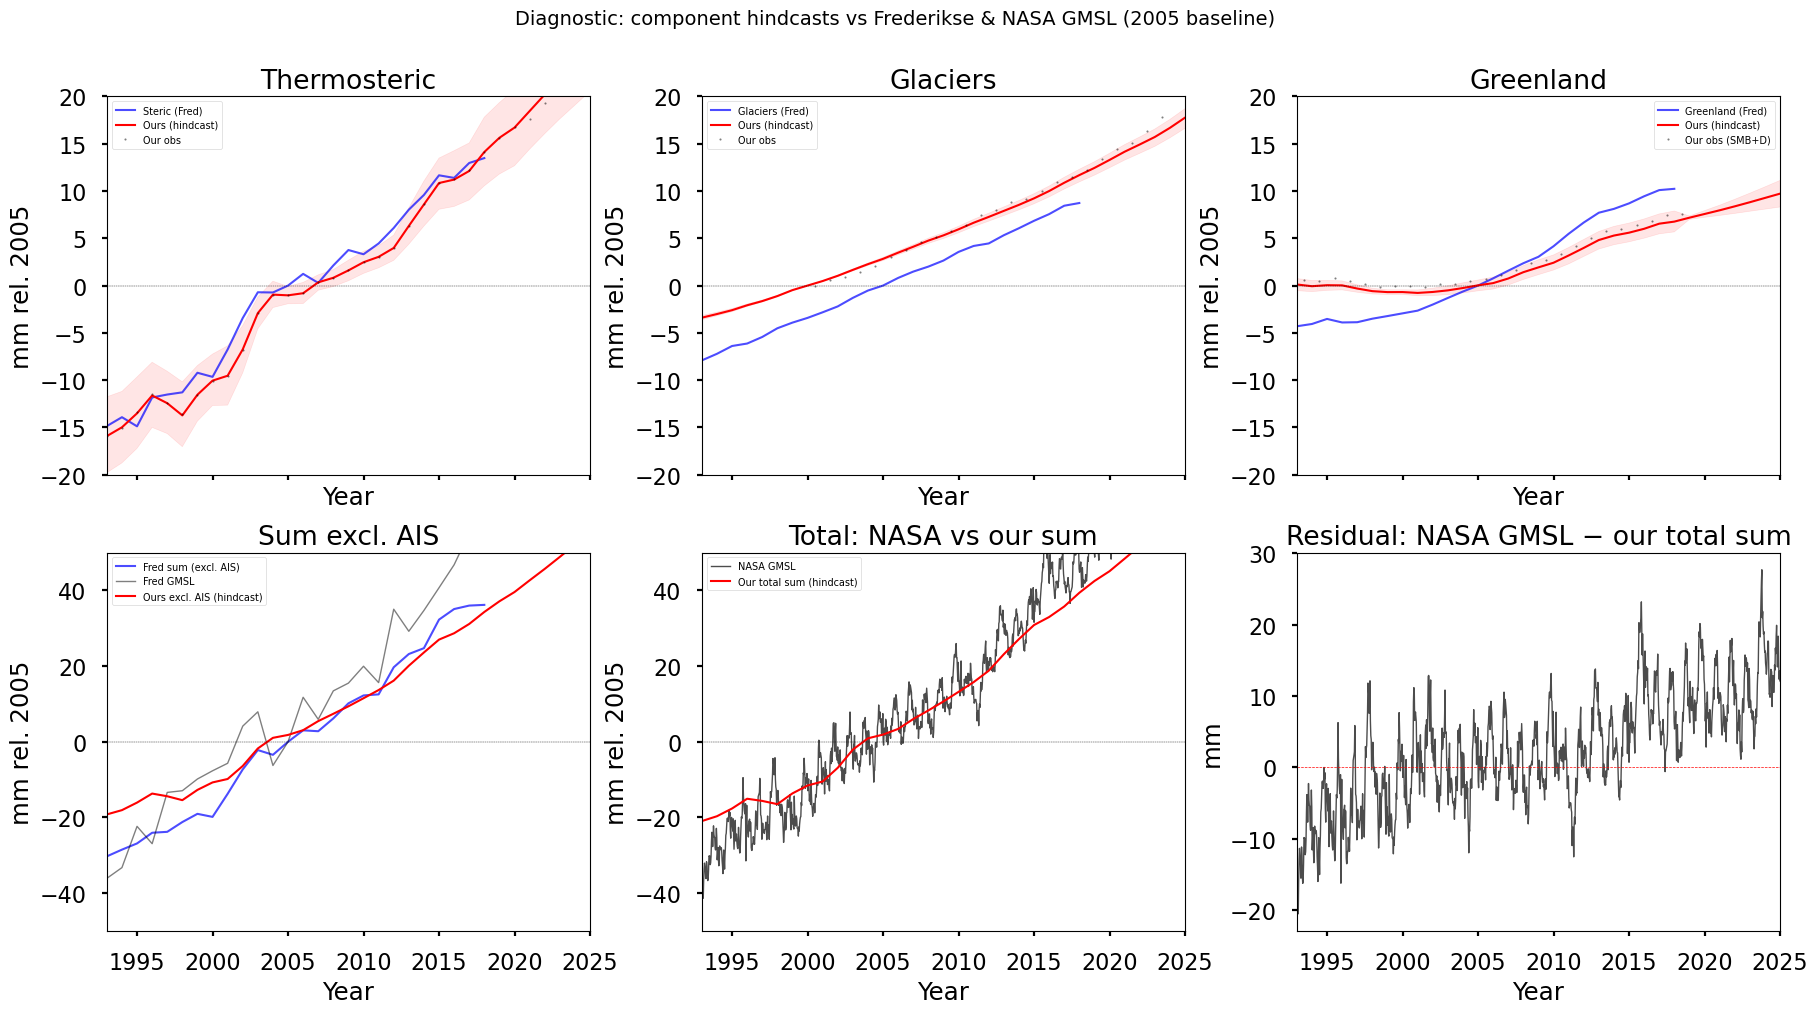

In [11]:
# ── Diagnostic 4: Our component hindcasts vs Frederikse (level comparison) ──
# Compare our historically-forced model output against Frederikse's
# per-component time series.  The pre-2005 period is SSP-independent;
# we pick any SSP as a carrier for the stored samples.

fig, axes = plt.subplots(2, 3, figsize=(18, 10), sharex=True)
axes = axes.ravel()

comp_fred_map = [
    ('ocean',     'Thermosteric', fred_steric,    'Steric (Fred)'),
    ('glacier',   'Glaciers',     fred_glaciers,  'Glaciers (Fred)'),
    ('greenland', 'Greenland',    fred_greenland, 'Greenland (Fred)'),
]

_ANY_SSP = PROJ_SSPS[0]  # historical period is SSP-independent
proj_mask_diag = proj_years >= 1990

for i, (hdf_key, label, fred_vals, fred_label) in enumerate(comp_fred_map):
    ax = axes[i]

    # Frederikse
    ax.plot(fred_year, fred_vals * M_TO_MM, 'b-', lw=1.5, alpha=0.7,
            label=fred_label)

    # Our hindcast median + CI
    if hdf_key in all_proj and _ANY_SSP in all_proj[hdf_key]:
        med = all_proj[hdf_key][_ANY_SSP]['median'] * M_TO_MM
        p5 = all_proj[hdf_key][_ANY_SSP]['p5'] * M_TO_MM
        p95 = all_proj[hdf_key][_ANY_SSP]['p95'] * M_TO_MM
        ax.plot(proj_years[proj_mask_diag], med[proj_mask_diag],
                'r-', lw=1.5, label='Ours (hindcast)')
        ax.fill_between(proj_years[proj_mask_diag],
                        p5[proj_mask_diag], p95[proj_mask_diag],
                        color='r', alpha=0.1)

    # Our component observations
    c = comp_obs[hdf_key]
    obs = c['observations']
    if 'years' in obs:
        ax.plot(obs['years'], obs['H_obs'] * M_TO_MM, 'k.', ms=3,
                alpha=0.5, label='Our obs')
    else:
        # Greenland: plot total = SMB + discharge
        yrs = obs['smb']['years']
        H_total = (obs['smb']['H_obs'] + obs['discharge']['H_obs']) * M_TO_MM
        ax.plot(yrs, H_total, 'k.', ms=3, alpha=0.5, label='Our obs (SMB+D)')

    ax.set_ylim(-20, 20)
    ax.set_title(label)
    ax.set_xlim(1990, 2025)
    ax.axhline(0, color='k', lw=0.3, ls='--')
    ax.legend(fontsize=7)
    ax.set_ylabel('mm rel. 2005')

# Panel 4: Sum excl. AIS — ours vs Frederikse
ax = axes[3]
fred_sum_no_ais = (fred_steric + fred_glaciers + fred_greenland + fred_tws)
ax.plot(fred_year, fred_sum_no_ais * M_TO_MM, 'b-', lw=1.5, alpha=0.7,
        label='Fred sum (excl. AIS)')
ax.plot(fred_year, fred_gmsl * M_TO_MM, 'k-', lw=1, alpha=0.5,
        label='Fred GMSL')

# Our sum excl. AIS (hindcast)
ais_labels_set = {'eais', 'apeninsula', 'wais'}
our_no_ais_med = np.zeros(len(proj_years))
for hdf_key in COMP_LABELS:
    if hdf_key in ais_labels_set:
        continue
    if hdf_key in all_proj and _ANY_SSP in all_proj[hdf_key]:
        our_no_ais_med += all_proj[hdf_key][_ANY_SSP]['median']
ax.plot(proj_years[proj_mask_diag], our_no_ais_med[proj_mask_diag] * M_TO_MM,
        'r-', lw=1.5, label='Ours excl. AIS (hindcast)')
ax.set_title('Sum excl. AIS')
ax.set_xlim(1990, 2025)
ax.axhline(0, color='k', lw=0.3, ls='--')
ax.legend(fontsize=7)
ax.set_ylabel('mm rel. 2005')
ax.set_ylim(-50, 50)

# Panel 5: NASA GMSL vs our total sum
ax = axes[4]
obs_mask_d = nasa_time >= 1993
ax.plot(nasa_time[obs_mask_d], nasa_gmsl_rb[obs_mask_d] * M_TO_MM,
        'k-', lw=1, alpha=0.7, label='NASA GMSL')
our_total_med = comp_projections[_ANY_SSP]['Total_sum']['median']
ax.plot(proj_years[proj_mask_diag], our_total_med[proj_mask_diag] * M_TO_MM,
        'r-', lw=1.5, label='Our total sum (hindcast)')
ax.set_title('Total: NASA vs our sum')
ax.set_xlim(1990, 2025)
ax.axhline(0, color='k', lw=0.3, ls='--')
ax.legend(fontsize=7)
ax.set_ylabel('mm rel. 2005')
ax.set_ylim(-50, 50)

# Panel 6: Residual — NASA minus our total sum (all components)
# All arithmetic in meters, convert to mm only for plotting
ax = axes[5]
our_total_interp = np.interp(nasa_time, proj_years, our_total_med)
residual_total = (nasa_gmsl_rb - our_total_interp) * M_TO_MM
ax.plot(nasa_time[obs_mask_d], residual_total[obs_mask_d], 'k-', lw=1, alpha=0.7)
ax.axhline(0, color='r', lw=0.5, ls='--')
ax.set_title('Residual: NASA GMSL − our total sum')
ax.set_xlim(1993, 2025)
ax.set_ylabel('mm')

for ax in axes:
    ax.set_xlabel('Year')

fig.suptitle('Diagnostic: component hindcasts vs Frederikse & NASA GMSL (2005 baseline)',
             fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

In [12]:
if RUN_ADDENDUM:
    # ── Diagnostic A4: Our component rates vs Frederikse component rates ──
    fred_comp_rates = {
        'Steric':    polyfit(fred_year[mask_fred], fred_steric[mask_fred], 1)[1] * M_TO_MM,
        'Glaciers':  polyfit(fred_year[mask_fred], fred_glaciers[mask_fred], 1)[1] * M_TO_MM,
        'Greenland': polyfit(fred_year[mask_fred], fred_greenland[mask_fred], 1)[1] * M_TO_MM,
        'TWS':       polyfit(fred_year[mask_fred], fred_tws[mask_fred], 1)[1] * M_TO_MM,
        'Antarctica':polyfit(fred_year[mask_fred], fred_antarctica[mask_fred], 1)[1] * M_TO_MM,
    }
    our_comp_rates = {}
    for hdf_key, label in COMP_LABELS.items():
        if hdf_key in all_proj and _ANY_SSP in all_proj[hdf_key]:
            med = all_proj[hdf_key][_ANY_SSP]['median']
            c = polyfit(proj_years[proj_mask_tr], med[proj_mask_tr], 1)
            our_comp_rates[label] = c[1] * M_TO_MM
    our_to_fred = {'Thermosteric': 'Steric', 'Glaciers': 'Glaciers',
                   'Greenland': 'Greenland', 'TWS': 'TWS'}
    print(f'Per-component rate comparison {trend_start}–{trend_end} (mm/yr, hindcast):')
    print(f'{"Component":<14} {"Ours":>10} {"Fred":>10} {"Diff":>10}')
    print('-' * 46)
    for label in ['Thermosteric', 'Glaciers', 'Greenland', 'TWS']:
        ours = our_comp_rates.get(label, np.nan)
        fred = fred_comp_rates.get(our_to_fred.get(label, label), np.nan)
        print(f'{label:<14} {ours:>10.3f} {fred:>10.3f} {ours - fred:>10.3f}')
    print()
    ais_rate_ours = sum(our_comp_rates.get(l, 0) for l in ['EAIS', 'Peninsula', 'WAIS'])
    ais_rate_fred = fred_comp_rates['Antarctica']
    print(f'{"AIS (total)":<14} {ais_rate_ours:>10.3f} {ais_rate_fred:>10.3f} '
          f'{ais_rate_ours - ais_rate_fred:>10.3f}')
    total_ours = sum(our_comp_rates.values())
    total_fred = sum(fred_comp_rates.values())
    print(f'{"Sum (all)":<14} {total_ours:>10.3f} {total_fred:>10.3f} '
          f'{total_ours - total_fred:>10.3f}')

Ocean (stored): 1950–2025, (2000, 76)
Glacier: 1950–2025
Greenland (stored): 1950–2025
WAIS (stored): 1950–2025
TWS (Frederikse): 1900–2018, extrapolated flat beyond 2018


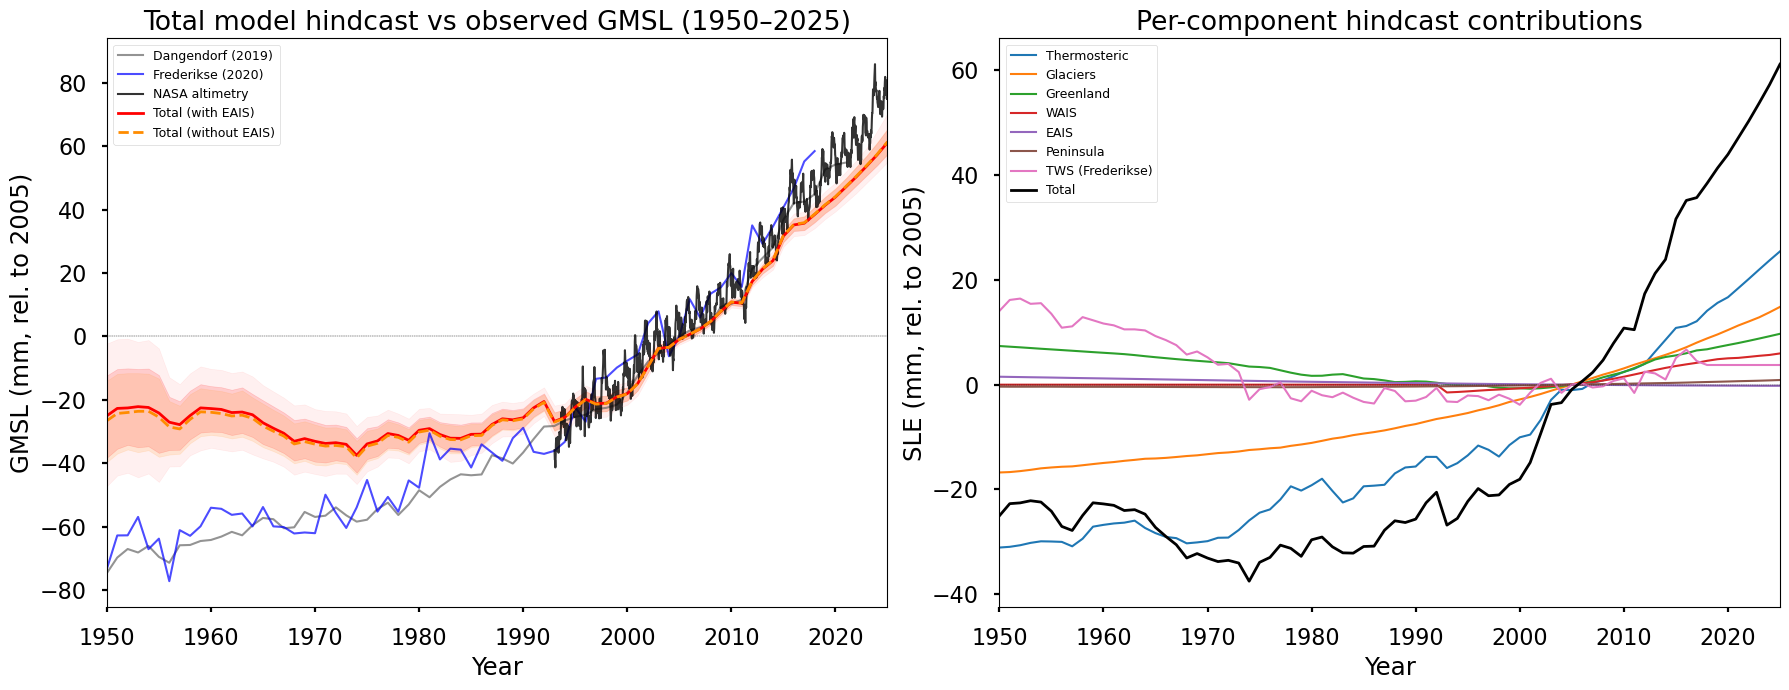


Hindcast 1950→2020 (mm):
  With EAIS:    69.0
  Without EAIS: 70.7
  Dangendorf:   128.9
  Frederikse (1950→2018): 131.8


In [13]:
# ── Diagnostic 6: GMST-forced hindcast vs observed GMSL ──
# Re-run T-forced component models with observed Berkeley Earth GMST
# and compare the total against Frederikse, Dangendorf, and NASA GMSL.
#
# Components re-run from posteriors: glacier, EAIS, peninsula
# Components using stored projections: ocean (hybrid NOAA+IPCC),
#   WAIS (scenario-based)
# TWS: Frederikse (2020) observations with MC sampling from sigma

from slr_projections import (
    project_component_level_ensemble,
)
import h5py

# ====== USER FLAGS ======
HIND_START = 1950   # left edge of plot
HIND_END   = 2025   # right edge of plot
# ========================

# ── Load Berkeley Earth monthly GMST (from 1850 for ODE spin-up) ──
with pd.HDFStore(H5_DIAG, 'r') as store:
    df_berk = store['/harmonized/df_berkeley_h']
    df_dang = store['/harmonized/df_dangendorf_h']

berk_time = np.array([t.year + (t.month - 0.5) / 12 for t in df_berk.index])
berk_temp = df_berk['temperature'].values

mask_1850 = berk_time >= 1850
T_monthly = berk_temp[mask_1850]
t_monthly = berk_time[mask_1850]

hind_years = np.arange(HIND_START, HIND_END + 1, dtype=float)

# Annual Berkeley Earth GMST (needed by downstream diagnostics)
berk_annual = df_berk[['temperature']].resample('YS').mean()
berk_annual['decimal_year'] = berk_annual.index.year + 0.5


# ── Load posteriors from HDF5 (non-ocean components) ──
h5_path = DEFAULT_H5_PATH
with h5py.File(h5_path, 'r') as f:
    gl_post = f['glacier/posteriors/posterior_samples'][:]
    gl_H0 = f['glacier/posteriors/H0_posterior'][:]
    gl_order = int(f['glacier'].attrs['model_order'])

    ea_post = f['eais/posteriors/posterior_samples'][:]
    ea_H0 = f['eais/posteriors/H0_posterior'][:]
    ea_order = int(f['eais'].attrs['model_order'])

    ap_post = f['apeninsula/posteriors/posterior_samples'][:]
    ap_H0 = f['apeninsula/posteriors/H0_posterior'][:]
    ap_order = int(f['apeninsula'].attrs['model_order'])

N_MC = 2000
SEED = 42

# ── Ocean: load stored samples (hybrid NOAA+IPCC, no ODE re-run) ──
_ANY_SSP = PROJ_SSPS[0]
stored_oc = all_proj['ocean'][_ANY_SSP]
ocean_samples = stored_oc['samples']
n_oc = min(N_MC, ocean_samples.shape[0])
ocean_samp_interp = np.zeros((n_oc, len(hind_years)))
for k in range(n_oc):
    ocean_samp_interp[k] = np.interp(hind_years, proj_years, ocean_samples[k])
ocean_med_interp = np.interp(hind_years, proj_years, stored_oc['median'])
print(f'Ocean (stored): {hind_years[0]:.0f}–{hind_years[-1]:.0f}, '
      f'{ocean_samp_interp.shape}')

# ── Glacier: level-space DOLS ──
glacier_hind = project_component_level_ensemble(
    posterior_samples=gl_post, H0_samples=gl_H0,
    temperature_monthly=T_monthly, time_monthly=t_monthly,
    projection_times=hind_years, baseline_year=BASELINE_YEAR,
    n_samples=N_MC, order=gl_order, seed=SEED + 1,
)
print(f'Glacier: {hind_years[0]:.0f}–{hind_years[-1]:.0f}')

# ── EAIS ──
eais_hind = project_component_level_ensemble(
    posterior_samples=ea_post, H0_samples=ea_H0,
    temperature_monthly=T_monthly, time_monthly=t_monthly,
    projection_times=hind_years, baseline_year=BASELINE_YEAR,
    n_samples=N_MC, order=ea_order, seed=SEED + 2,
)

# ── Peninsula ──
apen_hind = project_component_level_ensemble(
    posterior_samples=ap_post, H0_samples=ap_H0,
    temperature_monthly=T_monthly, time_monthly=t_monthly,
    projection_times=hind_years, baseline_year=BASELINE_YEAR,
    n_samples=N_MC, order=ap_order, seed=SEED + 3,
)

# ── Stored projections for components that can't be trivially re-run ──
# Pre-2005 is historical-forced (SSP-independent); post-2005 SSPs barely
# diverge over this short window.  Pick any SSP as carrier.
_ANY_SSP = PROJ_SSPS[0]

def _interp_stored(comp_name):
    """Interpolate stored MC samples onto hind_years."""
    stored = all_proj[comp_name][_ANY_SSP]
    samp_full = stored['samples']
    samp = np.zeros((samp_full.shape[0], len(hind_years)))
    for k in range(samp_full.shape[0]):
        samp[k] = np.interp(hind_years, proj_years, samp_full[k])
    med = np.interp(hind_years, proj_years, stored['median'])
    return samp, med

gr_samples, gr_med = _interp_stored('greenland')
print(f'Greenland (stored): {hind_years[0]:.0f}–{hind_years[-1]:.0f}')

wais_samples, wais_med = _interp_stored('wais')
print(f'WAIS (stored): {hind_years[0]:.0f}–{hind_years[-1]:.0f}')

# ── TWS: Frederikse (2020) observations ──
# Use observed TWS (1900–2018) with MC samples drawn from sigma,
# rebased to 2005. Extrapolate flat beyond 2018 (last observation).
fred_tws_raw = df_fred['tws'].values       # meters
fred_tws_sig = df_fred['tws_sigma'].values  # meters
idx_fred_tws_bl = np.argmin(np.abs(fred_year - BASELINE_YEAR))
fred_tws_rb = fred_tws_raw - fred_tws_raw[idx_fred_tws_bl]

rng_tws = np.random.default_rng(SEED + 5)
tws_samples = np.zeros((N_MC, len(hind_years)))
for k in range(N_MC):
    # Draw perturbed TWS on Frederikse years, then interpolate to hind_years
    tws_draw = fred_tws_rb + rng_tws.normal(0, fred_tws_sig)
    tws_samples[k] = np.interp(hind_years, fred_year, tws_draw)

tws_med = np.interp(hind_years, fred_year, fred_tws_rb)
print(f'TWS (Frederikse): {fred_year[0]:.0f}–{fred_year[-1]:.0f}, '
      f'extrapolated flat beyond 2018')

# ── Sum all components ──
# Interpolate ocean samples onto hind_years

n = min(n_oc, glacier_hind['samples'].shape[0],
        gr_samples.shape[0], wais_samples.shape[0], tws_samples.shape[0])
total_samples = (ocean_samp_interp[:n]
                 + glacier_hind['samples'][:n]
                 + eais_hind['samples'][:n]
                 + apen_hind['samples'][:n]
                 + gr_samples[:n]
                 + wais_samples[:n]
                 + tws_samples[:n])

total_med = np.median(total_samples, axis=0)
total_p5 = np.percentile(total_samples, 5, axis=0)
total_p17 = np.percentile(total_samples, 17, axis=0)
total_p83 = np.percentile(total_samples, 83, axis=0)
total_p95 = np.percentile(total_samples, 95, axis=0)

# ── Total without EAIS ──
total_no_eais = (ocean_samp_interp[:n]
                 + glacier_hind['samples'][:n]
                 + apen_hind['samples'][:n]
                 + gr_samples[:n]
                 + wais_samples[:n]
                 + tws_samples[:n])

total_no_eais_med = np.median(total_no_eais, axis=0)
total_no_eais_p17 = np.percentile(total_no_eais, 17, axis=0)
total_no_eais_p83 = np.percentile(total_no_eais, 83, axis=0)


# ── Observations: rebase Dangendorf to 2005 ──
dang_time = df_dang['decimal_year'].values
dang_gmsl = df_dang['gmsl'].values
idx_dang_bl = np.argmin(np.abs(dang_time - BASELINE_YEAR))
dang_gmsl_rb = dang_gmsl - dang_gmsl[idx_dang_bl]

# ── Plot ──
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Panel (a): Total hindcast vs observations
ax = axes[0]
dm = (dang_time >= HIND_START) & (dang_time <= HIND_END)
ax.plot(dang_time[dm], dang_gmsl_rb[dm] * M_TO_MM, color='0.4', lw=1.5,
        alpha=0.7, label='Dangendorf (2019)')
fm = (fred_year >= HIND_START) & (fred_year <= HIND_END)
ax.plot(fred_year[fm], fred_gmsl[fm] * M_TO_MM, 'b-', lw=1.5, alpha=0.7,
        label='Frederikse (2020)')
nm = (nasa_time >= max(1993, HIND_START)) & (nasa_time <= HIND_END)
ax.plot(nasa_time[nm], nasa_gmsl_rb[nm] * M_TO_MM, 'k-', lw=1.5, alpha=0.8,
        label='NASA altimetry')

ax.plot(hind_years, total_med * M_TO_MM, 'r-', lw=2,
        label='Total (with EAIS)')
ax.fill_between(hind_years, total_p17 * M_TO_MM, total_p83 * M_TO_MM,
                color='r', alpha=0.15)
ax.fill_between(hind_years, total_p5 * M_TO_MM, total_p95 * M_TO_MM,
                color='r', alpha=0.06)

ax.plot(hind_years, total_no_eais_med * M_TO_MM, '--', color='darkorange', lw=2,
        label='Total (without EAIS)')
ax.fill_between(hind_years, total_no_eais_p17 * M_TO_MM,
                total_no_eais_p83 * M_TO_MM,
                color='darkorange', alpha=0.12)

ax.set_xlim(HIND_START, HIND_END)
ax.set_xlabel('Year')
ax.set_ylabel('GMSL (mm, rel. to 2005)')
ax.set_title(f'Total model hindcast vs observed GMSL ({HIND_START}–{HIND_END})')
ax.axhline(0, color='k', lw=0.3, ls='--')
ax.legend(fontsize=9, loc='upper left')

# Panel (b): Per-component contributions
ax = axes[1]
ax.plot(hind_years, ocean_med_interp * M_TO_MM, label='Thermosteric', lw=1.5)
ax.plot(hind_years, glacier_hind['median'] * M_TO_MM, label='Glaciers', lw=1.5)
ax.plot(hind_years, gr_med * M_TO_MM, label='Greenland', lw=1.5)
ax.plot(hind_years, wais_med * M_TO_MM, label='WAIS', lw=1.5)
ax.plot(hind_years, eais_hind['median'] * M_TO_MM, label='EAIS', lw=1.5)
ax.plot(hind_years, apen_hind['median'] * M_TO_MM, label='Peninsula', lw=1.5)
ax.plot(hind_years, tws_med * M_TO_MM, label='TWS (Frederikse)', lw=1.5)
ax.plot(hind_years, total_med * M_TO_MM, 'k-', lw=2, label='Total')

ax.set_xlim(HIND_START, HIND_END)
ax.set_xlabel('Year')
ax.set_ylabel('SLE (mm, rel. to 2005)')
ax.set_title('Per-component hindcast contributions')
ax.axhline(0, color='k', lw=0.3, ls='--')
ax.legend(fontsize=9, loc='upper left')

plt.tight_layout()
plt.show()

# Summary at 2020
idx_2020 = np.argmin(np.abs(hind_years - 2020))
idx_start = 0
print(f'\nHindcast {HIND_START}→2020 (mm):')
print(f'  With EAIS:    {(total_med[idx_2020] - total_med[idx_start])*M_TO_MM:.1f}')
print(f'  Without EAIS: {(total_no_eais_med[idx_2020] - total_no_eais_med[idx_start])*M_TO_MM:.1f}')
d0 = dang_gmsl_rb[np.argmin(np.abs(dang_time - HIND_START))]
d1 = dang_gmsl_rb[np.argmin(np.abs(dang_time - 2020))]
print(f'  Dangendorf:   {(d1 - d0)*M_TO_MM:.1f}')
f0 = fred_gmsl[np.argmin(np.abs(fred_year - HIND_START))]
f1 = fred_gmsl[np.argmin(np.abs(fred_year - 2018))]
print(f'  Frederikse ({HIND_START}→2018): {(f1 - f0)*M_TO_MM:.1f}')

Rate-and-state hindcast: 1950–2024, tau=15.2 yr


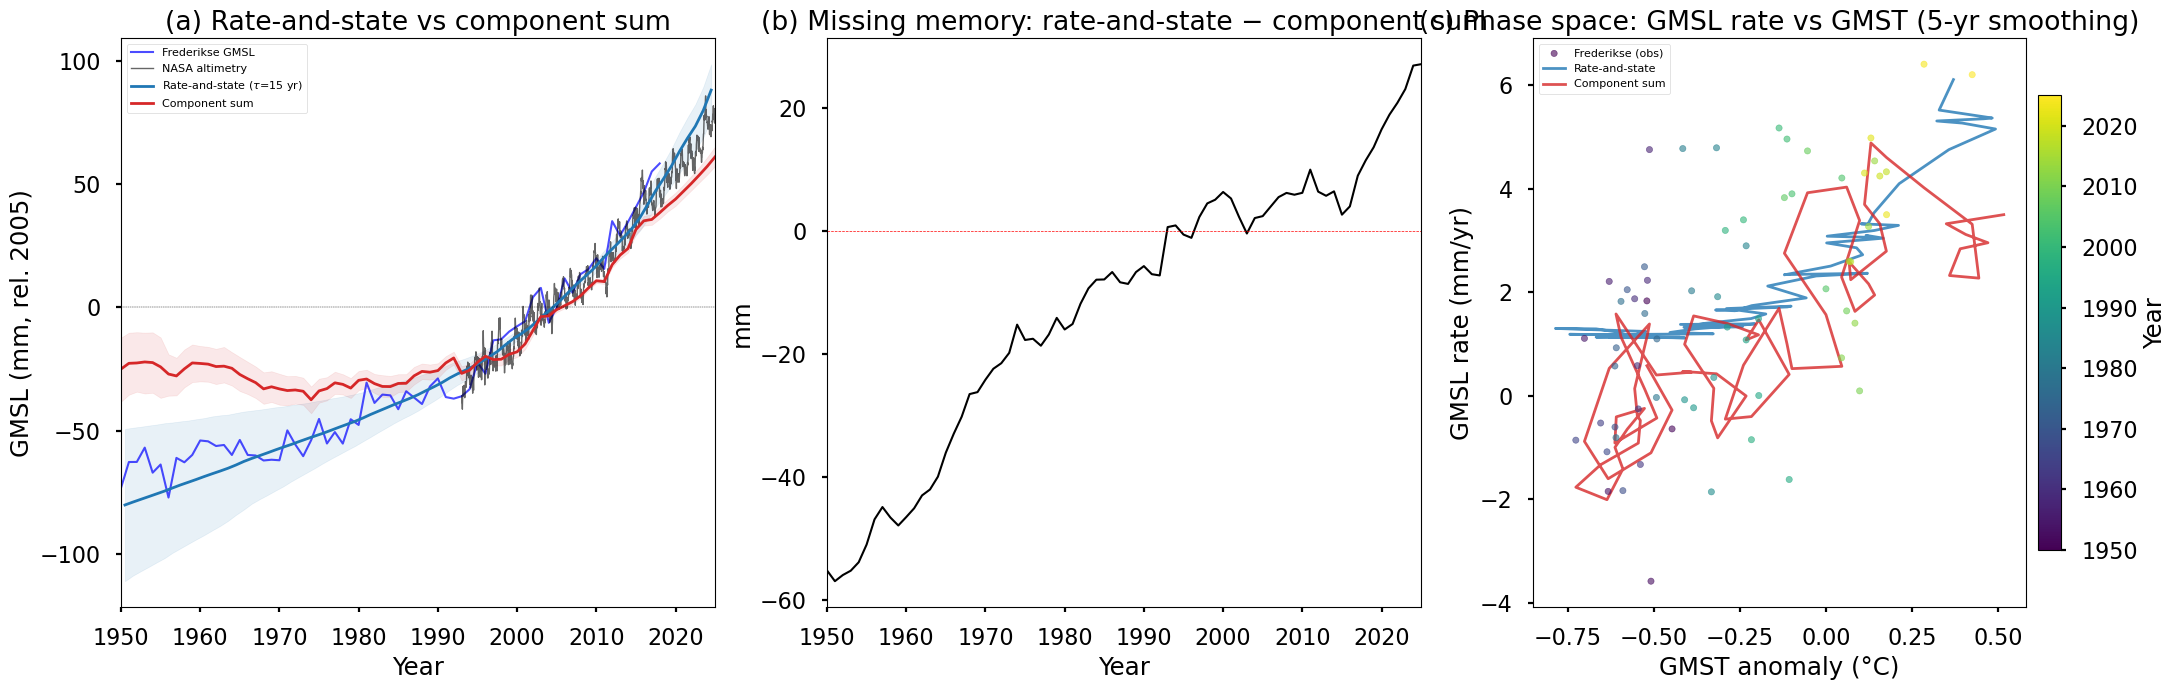


Residual (rate-and-state − component sum) at key years:
  1995: -0.6 mm
  2000: +6.3 mm
  2005: +2.4 mm
  2010: +6.2 mm
  2015: +2.6 mm
  2020: +16.5 mm

Mean absolute residual: 19.1 mm
Max absolute residual:  56.9 mm


In [14]:
# ── Diagnostic 7: Residual analysis — rate-and-state vs component sum ──
# Option 1: compare the rate-and-state GMSL hindcast (which fits the full
# observed GMSL well) against the component sum.  The residual reveals
# "missing memory" — slow response physics not captured by any single
# component model.
#
# Includes a phase-space plot: GMSL rate vs GMST.

import json as _json
from numpy.polynomial.polynomial import polyfit
from slr_projections import project_gmsl_state_ensemble

# ── Load rate-and-state calibration ──
with open('../data/processed/bayesian_ratestate_results.json') as f:
    rs_json = _json.load(f)

rs_cal = rs_json['calibration']
Z_94 = 1.881

coeffs_abcd = np.array([
    rs_cal['coefficients_mm_yr']['dalpha_dT'],
    rs_cal['coefficients_mm_yr']['alpha0'],
    rs_cal['coefficients_mm_yr']['trend'],
    rs_cal['coefficients_mm_yr']['d_diseq'],
]) / M_TO_MM  # → m/yr

hdi = rs_cal['hdi_94_mm_yr']
sigmas_mm = np.array([
    (hdi['dalpha_dT'][1] - hdi['dalpha_dT'][0]) / (2 * Z_94),
    (hdi['alpha0'][1] - hdi['alpha0'][0]) / (2 * Z_94),
    (hdi['trend'][1] - hdi['trend'][0]) / (2 * Z_94),
    (hdi['d_diseq'][1] - hdi['d_diseq'][0]) / (2 * Z_94),
])
cov_abcd = np.diag((sigmas_mm / M_TO_MM) ** 2)

tau_median = rs_cal['tau_yr']['median']
tau_lo, tau_hi = rs_cal['tau_yr']['hdi_94']
mu_log_tau = np.log(tau_median)
sigma_log_tau = (np.log(tau_hi) - np.log(tau_lo)) / (2 * Z_94)
rng_tau = np.random.default_rng(123)
tau_samples_rs = rng_tau.lognormal(mu_log_tau, sigma_log_tau, size=4000)

# ── Run rate-and-state hindcast with observed GMST only ──
# Build a single "hindcast" scenario from Berkeley Earth annual GMST
mask_rs_hind = ((berk_annual['decimal_year'] >= HIND_START)
                & (berk_annual['decimal_year'] <= HIND_END))
df_rs_temp = berk_annual[mask_rs_hind][['temperature', 'decimal_year']].copy()

rs_hind = project_gmsl_state_ensemble(
    coefficients=coeffs_abcd,
    coefficients_cov=cov_abcd,
    tau_samples=tau_samples_rs,
    temperature_projections={'hindcast': df_rs_temp},
    historical_temperature=T_monthly,
    historical_time=t_monthly,
    baseline_year=BASELINE_YEAR,
    baseline_gmsl=0.0,
    n_samples=N_MC,
    seed=42,
)

rs_df = rs_hind['scenarios']['hindcast']
rs_time = rs_df['decimal_year'].values
rs_gmsl = rs_df['gmsl'].values          # meters, median
rs_gmsl_lo = rs_df['gmsl_lower'].values
rs_gmsl_hi = rs_df['gmsl_upper'].values
print(f'Rate-and-state hindcast: {rs_time[0]:.0f}–{rs_time[-1]:.0f}, '
      f'tau={tau_median:.1f} yr')

# ── Compute residual: rate-and-state minus component sum ──
# Interpolate both onto common annual grid
rs_on_hind = np.interp(hind_years, rs_time, rs_gmsl)
residual_rs_comp = (rs_on_hind - total_med) * M_TO_MM  # mm

# ── Compute GMSL rates for phase-space plot ──
# Use centered finite differences on annual data for smoothed rates.
SMOOTH_WIN = 5  # years, for rate estimation

def _smooth_rate(time, level, win=SMOOTH_WIN):
    """Smoothed rate via linear fit in sliding window."""
    rates = np.full_like(time, np.nan)
    hw = win // 2
    for i in range(hw, len(time) - hw):
        c = polyfit(time[i-hw:i+hw+1], level[i-hw:i+hw+1], 1)
        rates[i] = c[1]
    return rates

# Observed GMSL rate (Frederikse annual)
fm_hind = (fred_year >= HIND_START) & (fred_year <= HIND_END)
fred_rate = _smooth_rate(fred_year[fm_hind], fred_gmsl[fm_hind]) * M_TO_MM
fred_T_annual = np.interp(fred_year[fm_hind], berk_annual['decimal_year'].values,
                          berk_annual['temperature'].values)

# Rate-and-state rate
rs_rate = _smooth_rate(rs_time, rs_gmsl) * M_TO_MM
rs_T = np.interp(rs_time, berk_annual['decimal_year'].values,
                 berk_annual['temperature'].values)

# Component sum rate
comp_rate = _smooth_rate(hind_years, total_med) * M_TO_MM
comp_T = np.interp(hind_years, berk_annual['decimal_year'].values,
                   berk_annual['temperature'].values)

# ── Plot: 3 panels ──
fig, axes = plt.subplots(1, 3, figsize=(22, 7))

# Panel (a): Level comparison — rate-and-state vs component sum vs obs
ax = axes[0]
fm_plot = (fred_year >= HIND_START) & (fred_year <= HIND_END)
ax.plot(fred_year[fm_plot], fred_gmsl[fm_plot] * M_TO_MM,
        'b-', lw=1.5, alpha=0.7, label='Frederikse GMSL')
nm_plot = (nasa_time >= max(1993, HIND_START)) & (nasa_time <= HIND_END)
ax.plot(nasa_time[nm_plot], nasa_gmsl_rb[nm_plot] * M_TO_MM,
        'k-', lw=1, alpha=0.6, label='NASA altimetry')

ax.plot(rs_time, rs_gmsl * M_TO_MM, color='tab:blue', lw=2,
        label=f'Rate-and-state ($\\tau$={tau_median:.0f} yr)')
ax.fill_between(rs_time, rs_gmsl_lo * M_TO_MM, rs_gmsl_hi * M_TO_MM,
                color='tab:blue', alpha=0.1)
ax.plot(hind_years, total_med * M_TO_MM, color='tab:red', lw=2,
        label='Component sum')
ax.fill_between(hind_years, total_p17 * M_TO_MM, total_p83 * M_TO_MM,
                color='tab:red', alpha=0.1)

ax.set_xlim(HIND_START, HIND_END)
ax.set_xlabel('Year')
ax.set_ylabel('GMSL (mm, rel. 2005)')
ax.set_title('(a) Rate-and-state vs component sum')
ax.axhline(0, color='k', lw=0.3, ls='--')
ax.legend(fontsize=8, loc='upper left')

# Panel (b): Residual — rate-and-state minus component sum
ax = axes[1]
ax.plot(hind_years, residual_rs_comp, 'k-', lw=1.5)
ax.axhline(0, color='r', lw=0.5, ls='--')
ax.set_xlim(HIND_START, HIND_END)
ax.set_xlabel('Year')
ax.set_ylabel('mm')
ax.set_title('(b) Missing memory: rate-and-state − component sum')

# Panel (c): Phase-space — GMSL rate vs GMST
ax = axes[2]
# Observed (Frederikse) as scatter
valid_f = np.isfinite(fred_rate)
ax.scatter(fred_T_annual[valid_f], fred_rate[valid_f],
           c=fred_year[fm_hind][valid_f], cmap='viridis', s=20,
           alpha=0.6, zorder=3, label='Frederikse (obs)')

# Rate-and-state as blue line
valid_rs = np.isfinite(rs_rate)
ax.plot(rs_T[valid_rs], rs_rate[valid_rs],
        color='tab:blue', lw=2, alpha=0.8, label='Rate-and-state')

# Component sum as red line
valid_c = np.isfinite(comp_rate)
ax.plot(comp_T[valid_c], comp_rate[valid_c],
        color='tab:red', lw=2, alpha=0.8, label='Component sum')

ax.set_xlabel('GMST anomaly (°C)')
ax.set_ylabel('GMSL rate (mm/yr)')
ax.set_title(f'(c) Phase space: GMSL rate vs GMST ({SMOOTH_WIN}-yr smoothing)')
ax.legend(fontsize=8)

# Colorbar for year
sm = plt.cm.ScalarMappable(cmap='viridis',
                           norm=plt.Normalize(HIND_START, HIND_END))
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, shrink=0.8, pad=0.02)
cbar.set_label('Year')

plt.tight_layout()
plt.show()

# ── Summary statistics ──
idx_2020 = np.argmin(np.abs(hind_years - 2020))
print(f'\nResidual (rate-and-state − component sum) at key years:')
for yr in [1995, 2000, 2005, 2010, 2015, 2020]:
    idx = np.argmin(np.abs(hind_years - yr))
    print(f'  {yr}: {residual_rs_comp[idx]:+.1f} mm')

print(f'\nMean absolute residual: {np.nanmean(np.abs(residual_rs_comp)):.1f} mm')
print(f'Max absolute residual:  {np.nanmax(np.abs(residual_rs_comp)):.1f} mm')

Calibration: full NASA altimetry 1993–2025
  N rate observations: 32
  GMST range: -0.26 – 0.74 °C
  Mean rate residual: 0.87 mm/yr
  Rate residual scatter: 3.35 mm/yr

Bayesian update (full NASA altimetry):
Param                             Prior          Posterior    Shift
------------------------------------------------------------------
C_T (Gt/yr/°C)          -200 ± 80         -196.6 ± 79.5     +0.04 σ
C_T2 (Gt/yr/°C²)         -50 ± 30          -50.2 ± 30.0     -0.01 σ
  Posterior corr(C_T, C_T2) = -0.002

  OLS (no prior): C_T = 1833, C_T2 = -3832

Structural uncertainty (cumulative RMS of 5-yr smoothed residual):
  Baseline: 2005 (σ = 0 by construction)
  1993: σ_struct = 3.0 mm, σ_param(66%) ≈ 2.8 mm
  2000: σ_struct = 3.7 mm, σ_param(66%) ≈ 2.1 mm
  2010: σ_struct = 4.7 mm, σ_param(66%) ≈ 0.9 mm
  2020: σ_struct = 8.7 mm, σ_param(66%) ≈ 2.8 mm


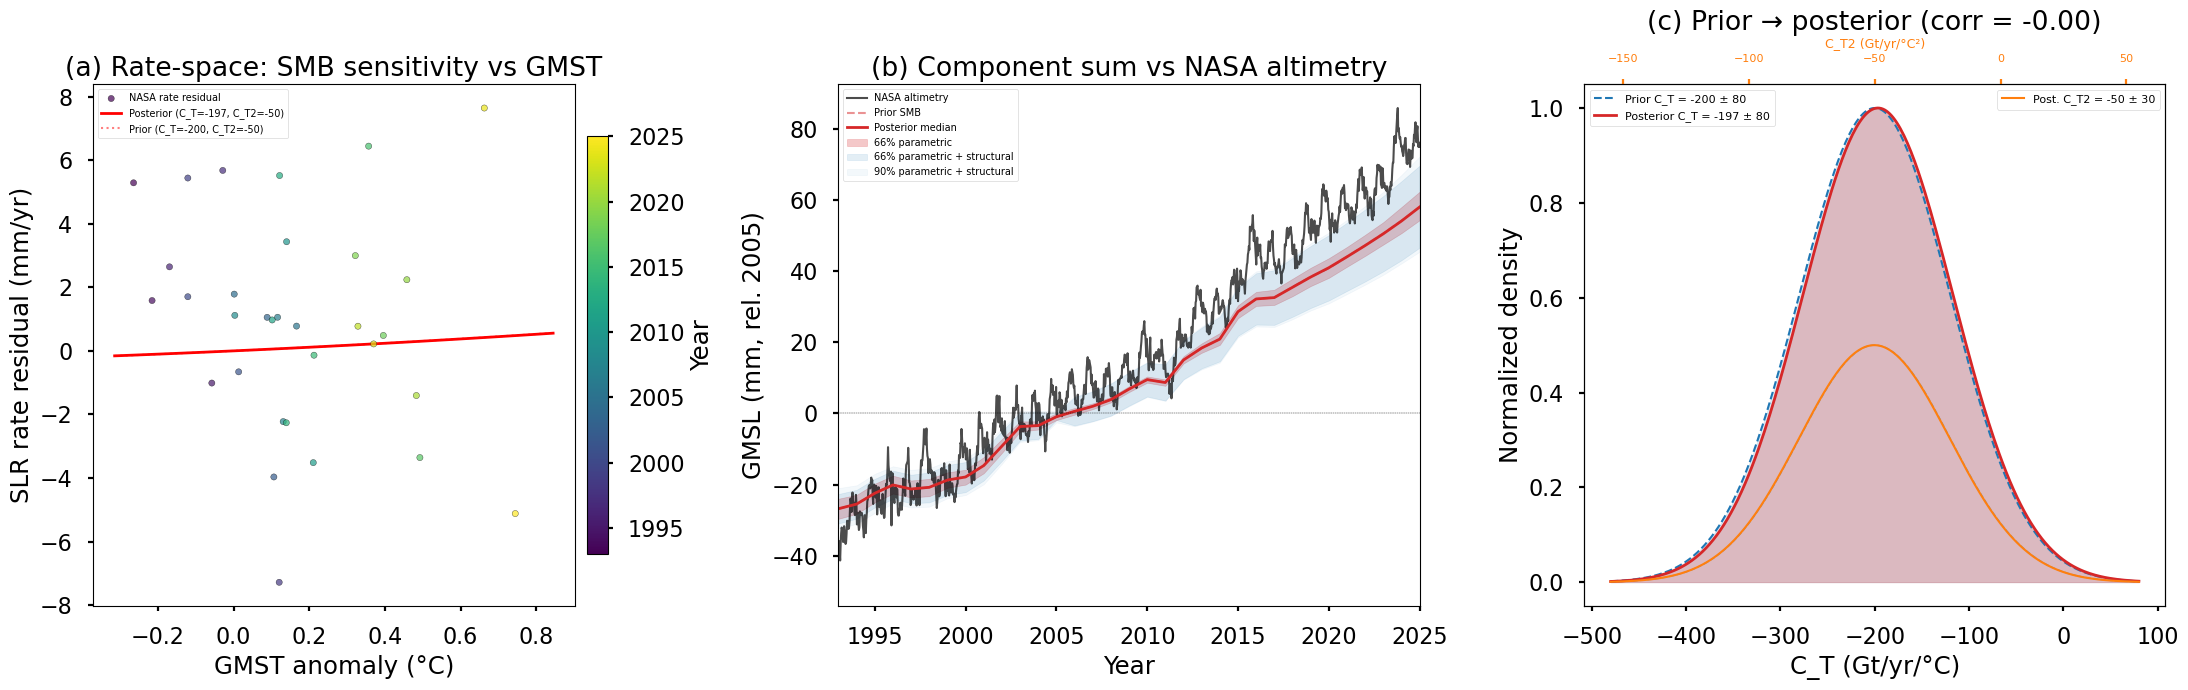


Greenland SMB rate (posterior):
  2000 (T=-0.12°C): prior 23 Gt/yr → post 23 Gt/yr (-0.06 mm/yr SLR)
  2020 (T=0.47°C): prior -105 Gt/yr → post -104 Gt/yr (0.29 mm/yr SLR)

  RMS vs NASA (1993–2025): prior 10.1 mm, posterior 10.1 mm


In [15]:
# ── Diagnostic 8: Top-down calibration of Greenland SMB sensitivity ──
# Calibrate C_T and C_T2 against the full NASA altimetry GMSL record,
# using the rate-space residual (NASA rate minus known-component rate).
#
# Known components: ocean, glacier, EAIS, peninsula, GrIS discharge, WAIS, TWS
# Free parameters: C_T, C_T2 (fit in rate space against NASA GMSL)
#
# Uncertainty decomposition:
#   Parametric: from MC propagation of all component posteriors + C_T/C_T2
#   Structural: from cumulative RMS of smoothed (NASA − model) residual,
#               growing outward from BASELINE_YEAR

import h5py
from scipy.stats import norm
from numpy.polynomial.polynomial import polyfit

GT_TO_M_SLE = 1.0 / 362500.0

# ====== USER FLAGS ======
CAL_START    = 1993          # calibration window start (NASA altimetry begins)
CAL_END      = 2025          # calibration window end
SMOOTH_WIN   = 5             # years, for structural uncertainty smoothing
# NOTE: BASELINE_YEAR is defined upstream (currently 2005.0).
# To change the baseline, update BASELINE_YEAR in the imports cell or config.
# =========================

# ── Load Greenland discharge-only from stored projections ──
_ANY_SSP = PROJ_SSPS[0]
with h5py.File(str(DEFAULT_H5_PATH), 'r') as f:
    dyn_samp_full = f[f'greenland/projections_discharge/{_ANY_SSP}/samples'][:]
    dyn_med_full = f[f'greenland/projections_discharge/{_ANY_SSP}/median'][:]

n_dyn = min(N_MC, dyn_samp_full.shape[0])
dyn_samp = np.zeros((n_dyn, len(hind_years)))
for k in range(n_dyn):
    dyn_samp[k] = np.interp(hind_years, proj_years, dyn_samp_full[k])

# ── Build "known" component sum (everything except GrIS SMB) ──
n = min(ocean_samp_interp.shape[0], glacier_hind['samples'].shape[0],
        eais_hind['samples'].shape[0], apen_hind['samples'].shape[0],
        n_dyn, wais_samples.shape[0], tws_samples.shape[0])
known_samples = (ocean_samp_interp[:n]
                 + glacier_hind['samples'][:n]
                 + eais_hind['samples'][:n]
                 + apen_hind['samples'][:n]
                 + dyn_samp[:n]
                 + wais_samples[:n]
                 + tws_samples[:n])
known_med = np.median(known_samples, axis=0)

# ── NASA GMSL smoothed to annual resolution ──
nasa_annual_years = np.arange(CAL_START, CAL_END + 1, dtype=float)
nasa_annual_gmsl = np.zeros(len(nasa_annual_years))
for i, yr in enumerate(nasa_annual_years):
    mask = (nasa_time >= yr - 0.5) & (nasa_time < yr + 0.5)
    if np.sum(mask) > 0:
        nasa_annual_gmsl[i] = np.mean(nasa_gmsl_rb[mask])
    else:
        nasa_annual_gmsl[i] = np.interp(yr, nasa_time, nasa_gmsl_rb)

known_annual = np.interp(nasa_annual_years, hind_years, known_med)

# ── Rate residual: NASA rate minus known-component rate ──
nasa_rate = np.diff(nasa_annual_gmsl) / np.diff(nasa_annual_years)
known_rate = np.diff(known_annual) / np.diff(nasa_annual_years)
rate_years = 0.5 * (nasa_annual_years[:-1] + nasa_annual_years[1:])
residual_rate = nasa_rate - known_rate

# GMST at rate midpoints
T_rate = np.interp(rate_years, berk_annual['decimal_year'].values,
                   berk_annual['temperature'].values)

print(f'Calibration: full NASA altimetry {CAL_START}–{CAL_END}')
print(f'  N rate observations: {len(residual_rate)}')
print(f'  GMST range: {T_rate.min():.2f} – {T_rate.max():.2f} °C')
print(f'  Mean rate residual: {np.mean(residual_rate)*M_TO_MM:.2f} mm/yr')

# ── Design matrix (rate space, 2 parameters) ──
X = np.column_stack([
    -GT_TO_M_SLE * T_rate,
    -GT_TO_M_SLE * T_rate**2,
])
y = residual_rate

# ── Priors ──
mu_prior = np.array([-200.0, -50.0])
sigma_prior = np.array([80.0, 30.0])
Sigma_prior_inv = np.diag(1.0 / sigma_prior**2)

# ── Observation noise (data-driven) ──
beta_ols = np.linalg.lstsq(X, y, rcond=None)[0]
sigma_rate = np.std(y - X @ beta_ols)
sigma_rate = max(sigma_rate, 0.0003)
print(f'  Rate residual scatter: {sigma_rate*M_TO_MM:.2f} mm/yr')

# ── Conjugate Bayesian update ──
XtX = X.T @ X
Xty = X.T @ y
Sigma_post_inv = Sigma_prior_inv + XtX / sigma_rate**2
Sigma_post = np.linalg.inv(Sigma_post_inv)
mu_post = Sigma_post @ (Sigma_prior_inv @ mu_prior + Xty / sigma_rate**2)
sigma_post = np.sqrt(np.diag(Sigma_post))
corr_post = Sigma_post[0, 1] / (sigma_post[0] * sigma_post[1])

print(f'\nBayesian update (full NASA altimetry):')
print(f'{"Param":<20} {"Prior":>18} {"Posterior":>18} {"Shift":>8}')
print('-' * 66)
for i, name in enumerate(['C_T (Gt/yr/°C)', 'C_T2 (Gt/yr/°C²)']):
    shift = (mu_post[i] - mu_prior[i]) / sigma_prior[i]
    print(f'{name:<20} {mu_prior[i]:>7.0f} ± {sigma_prior[i]:<6.0f}'
          f'    {mu_post[i]:>7.1f} ± {sigma_post[i]:<6.1f}  {shift:>+6.2f} σ')
print(f'  Posterior corr(C_T, C_T2) = {corr_post:.3f}')
print(f'\n  OLS (no prior): C_T = {beta_ols[0]:.0f}, C_T2 = {beta_ols[1]:.0f}')

# ── Reconstruct posterior SMB on full hind_years ──
T_ann = np.interp(hind_years, berk_annual['decimal_year'].values,
                  berk_annual['temperature'].values)
idx_bl = np.argmin(np.abs(hind_years - BASELINE_YEAR))

rng_post = np.random.default_rng(99)
beta_draws = rng_post.multivariate_normal(mu_post, Sigma_post, size=N_MC)

smb_post_samples = np.zeros((N_MC, len(hind_years)))
for k in range(N_MC):
    smb_rate_gt = beta_draws[k, 0] * T_ann + beta_draws[k, 1] * T_ann**2
    slr_rate = -smb_rate_gt * GT_TO_M_SLE
    smb_post_samples[k] = np.cumsum(slr_rate) * 1.0
    smb_post_samples[k] -= smb_post_samples[k, idx_bl]

smb_post_med = np.median(smb_post_samples, axis=0)

# Prior SMB
smb_prior_samples = np.zeros((N_MC, len(hind_years)))
beta_prior_draws = rng_post.multivariate_normal(mu_prior, np.diag(sigma_prior**2), size=N_MC)
for k in range(N_MC):
    smb_rate_gt = beta_prior_draws[k, 0] * T_ann + beta_prior_draws[k, 1] * T_ann**2
    slr_rate = -smb_rate_gt * GT_TO_M_SLE
    smb_prior_samples[k] = np.cumsum(slr_rate) * 1.0
    smb_prior_samples[k] -= smb_prior_samples[k, idx_bl]
smb_prior_med = np.median(smb_prior_samples, axis=0)

# ── Updated total (parametric uncertainty) ──
total_updated = known_samples[:N_MC] + smb_post_samples[:N_MC]
total_upd_med = np.median(total_updated, axis=0)
total_upd_p17 = np.percentile(total_updated, 17, axis=0)
total_upd_p83 = np.percentile(total_updated, 83, axis=0)
total_upd_p5 = np.percentile(total_updated, 5, axis=0)
total_upd_p95 = np.percentile(total_updated, 95, axis=0)

total_prior = known_samples[:N_MC] + smb_prior_samples[:N_MC]
total_prior_med = np.median(total_prior, axis=0)

# ── Structural uncertainty ──
# Compute residual between NASA GMSL and our posterior total (level space)
total_upd_on_nasa_ann = np.interp(nasa_annual_years, hind_years, total_upd_med)
level_resid = nasa_annual_gmsl - total_upd_on_nasa_ann  # meters

# Low-pass filter: running mean to isolate structural (multi-year) error
hw = SMOOTH_WIN // 2
level_resid_smooth = np.full_like(level_resid, np.nan)
for j in range(hw, len(level_resid) - hw):
    level_resid_smooth[j] = np.mean(level_resid[j - hw:j + hw + 1])
# Fill edges with nearest valid value
level_resid_smooth[:hw] = level_resid_smooth[hw]
level_resid_smooth[-hw:] = level_resid_smooth[-hw - 1]

# Cumulative RMS growing outward from BASELINE_YEAR
# For each year, compute RMS of smoothed residual from BASELINE_YEAR to that year
idx_bl_nasa = np.argmin(np.abs(nasa_annual_years - BASELINE_YEAR))
sigma_struct_nasa = np.zeros(len(nasa_annual_years))
for j in range(len(nasa_annual_years)):
    if j == idx_bl_nasa:
        sigma_struct_nasa[j] = 0.0
    elif j > idx_bl_nasa:
        seg = level_resid_smooth[idx_bl_nasa:j + 1]
        sigma_struct_nasa[j] = np.sqrt(np.mean(seg**2))
    else:
        seg = level_resid_smooth[j:idx_bl_nasa + 1]
        sigma_struct_nasa[j] = np.sqrt(np.mean(seg**2))

# Interpolate structural σ onto hind_years
sigma_struct = np.interp(hind_years, nasa_annual_years, sigma_struct_nasa)
# Zero at baseline by construction
sigma_struct[idx_bl] = 0.0

# Combined CI: parametric + structural in quadrature
param_sigma_17 = (total_upd_med - total_upd_p17)  # asymmetric, but approximate
param_sigma_83 = (total_upd_p83 - total_upd_med)
param_sigma_5 = (total_upd_med - total_upd_p5)
param_sigma_95 = (total_upd_p95 - total_upd_med)

combined_lo17 = total_upd_med - np.sqrt(param_sigma_17**2 + sigma_struct**2)
combined_hi83 = total_upd_med + np.sqrt(param_sigma_83**2 + sigma_struct**2)
combined_lo5 = total_upd_med - np.sqrt(param_sigma_5**2 + sigma_struct**2)
combined_hi95 = total_upd_med + np.sqrt(param_sigma_95**2 + sigma_struct**2)

# TWS uncertainty for context
tws_sig_hind = np.interp(hind_years, fred_year, fred_tws_sig)
tws_sig_hind[hind_years > fred_year[-1]] = fred_tws_sig[-1]

print(f'\nStructural uncertainty (cumulative RMS of {SMOOTH_WIN}-yr smoothed residual):')
print(f'  Baseline: {BASELINE_YEAR:.0f} (σ = 0 by construction)')
for yr in [1993, 2000, 2010, 2020]:
    if yr >= HIND_START:
        idx = np.argmin(np.abs(hind_years - yr))
        print(f'  {yr}: σ_struct = {sigma_struct[idx]*M_TO_MM:.1f} mm, '
              f'σ_param(66%) ≈ {0.5*(param_sigma_17[idx]+param_sigma_83[idx])*M_TO_MM:.1f} mm')

# ── Plot: 3 panels ──
fig, axes = plt.subplots(1, 3, figsize=(22, 7))

# Panel (a): Rate-space fit
ax = axes[0]
ax.scatter(T_rate, residual_rate * M_TO_MM, c=rate_years, cmap='viridis',
           s=20, alpha=0.7, zorder=3, edgecolors='k', linewidths=0.3,
           label='NASA rate residual')

T_grid = np.linspace(T_rate.min() - 0.05, T_rate.max() + 0.1, 100)
fit_post = -GT_TO_M_SLE * (mu_post[0] * T_grid + mu_post[1] * T_grid**2) * M_TO_MM
fit_prior = -GT_TO_M_SLE * (mu_prior[0] * T_grid + mu_prior[1] * T_grid**2) * M_TO_MM
ax.plot(T_grid, fit_post, 'r-', lw=2,
        label=f'Posterior (C_T={mu_post[0]:.0f}, C_T2={mu_post[1]:.0f})')
ax.plot(T_grid, fit_prior, 'r:', lw=1.5, alpha=0.5,
        label=f'Prior (C_T={mu_prior[0]:.0f}, C_T2={mu_prior[1]:.0f})')

ax.set_xlabel('GMST anomaly (°C)')
ax.set_ylabel('SLR rate residual (mm/yr)')
ax.set_title('(a) Rate-space: SMB sensitivity vs GMST')
ax.legend(fontsize=7, loc='upper left')
sm = plt.cm.ScalarMappable(cmap='viridis',
                           norm=plt.Normalize(CAL_START, CAL_END))
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, shrink=0.8, pad=0.02)
cbar.set_label('Year')

# Panel (b): Total model vs NASA — parametric + structural uncertainty
ax = axes[1]
nm_plot = (nasa_time >= 1993) & (nasa_time <= HIND_END)
ax.plot(nasa_time[nm_plot], nasa_gmsl_rb[nm_plot] * M_TO_MM,
        'k-', lw=1.5, alpha=0.7, label='NASA altimetry')

ax.plot(hind_years, total_prior_med * M_TO_MM, color='tab:red', lw=1.5, ls='--',
        alpha=0.5, label='Prior SMB')
ax.plot(hind_years, total_upd_med * M_TO_MM, color='tab:red', lw=2,
        label='Posterior median')

# Parametric uncertainty (inner)
ax.fill_between(hind_years, total_upd_p17 * M_TO_MM, total_upd_p83 * M_TO_MM,
                color='tab:red', alpha=0.25,
                label='66% parametric')

# Combined parametric + structural (outer)
ax.fill_between(hind_years, combined_lo17 * M_TO_MM, combined_hi83 * M_TO_MM,
                color='tab:blue', alpha=0.12,
                label='66% parametric + structural')
ax.fill_between(hind_years, combined_lo5 * M_TO_MM, combined_hi95 * M_TO_MM,
                color='tab:blue', alpha=0.05,
                label='90% parametric + structural')

ax.set_xlim(1993, HIND_END)
ax.set_xlabel('Year')
ax.set_ylabel('GMSL (mm, rel. 2005)')
ax.set_title('(b) Component sum vs NASA altimetry')
ax.axhline(0, color='k', lw=0.3, ls='--')
ax.legend(fontsize=7, loc='upper left')

# Panel (c): Prior vs posterior marginals
ax = axes[2]
ct_grid = np.linspace(mu_prior[0] - 3.5*sigma_prior[0],
                      mu_prior[0] + 3.5*sigma_prior[0], 300)
prior_ct = norm.pdf(ct_grid, mu_prior[0], sigma_prior[0])
post_ct = norm.pdf(ct_grid, mu_post[0], sigma_post[0])
ax.fill_between(ct_grid, prior_ct / prior_ct.max(), alpha=0.15, color='tab:blue')
ax.plot(ct_grid, prior_ct / prior_ct.max(), 'tab:blue', ls='--', lw=1.5,
        label=f'Prior C_T = {mu_prior[0]:.0f} ± {sigma_prior[0]:.0f}')
ax.fill_between(ct_grid, post_ct / post_ct.max(), alpha=0.25, color='tab:red')
ax.plot(ct_grid, post_ct / post_ct.max(), 'tab:red', lw=2,
        label=f'Posterior C_T = {mu_post[0]:.0f} ± {sigma_post[0]:.0f}')

ax2 = ax.twiny()
ct2_grid = np.linspace(mu_prior[1] - 3.5*sigma_prior[1],
                       mu_prior[1] + 3.5*sigma_prior[1], 300)
prior_ct2 = norm.pdf(ct2_grid, mu_prior[1], sigma_prior[1])
post_ct2 = norm.pdf(ct2_grid, mu_post[1], sigma_post[1])
ax2.plot(ct2_grid, prior_ct2 / prior_ct2.max() * 0.5, color='tab:blue',
         ls='--', lw=1, alpha=0.6)
ax2.plot(ct2_grid, post_ct2 / post_ct2.max() * 0.5, color='tab:orange', lw=1.5,
         label=f'Post. C_T2 = {mu_post[1]:.0f} ± {sigma_post[1]:.0f}')
ax2.set_xlabel('C_T2 (Gt/yr/°C²)', fontsize=9, color='tab:orange')
ax2.tick_params(axis='x', labelsize=8, colors='tab:orange')

ax.set_xlabel('C_T (Gt/yr/°C)')
ax.set_ylabel('Normalized density')
ax.set_title(f'(c) Prior → posterior (corr = {corr_post:.2f})')
ax.legend(fontsize=8, loc='upper left')
ax2.legend(fontsize=8, loc='upper right')

plt.tight_layout()
plt.show()

# ── Summary ──
T_2020 = T_ann[np.argmin(np.abs(hind_years - 2020))]
T_2000 = T_ann[np.argmin(np.abs(hind_years - 2000))]
print(f'\nGreenland SMB rate (posterior):')
for yr, T_yr in [(2000, T_2000), (2020, T_2020)]:
    rate_prior = mu_prior[0] * T_yr + mu_prior[1] * T_yr**2
    rate_post = mu_post[0] * T_yr + mu_post[1] * T_yr**2
    print(f'  {yr} (T={T_yr:.2f}°C): prior {rate_prior:.0f} Gt/yr '
          f'→ post {rate_post:.0f} Gt/yr '
          f'({-rate_post*GT_TO_M_SLE*M_TO_MM:.2f} mm/yr SLR)')

total_upd_on_nasa = np.interp(nasa_time, hind_years, total_upd_med)
total_pri_on_nasa = np.interp(nasa_time, hind_years, total_prior_med)
m = (nasa_time >= 1993) & (nasa_time <= 2025)
rms_post = np.sqrt(np.mean((nasa_gmsl_rb[m] - total_upd_on_nasa[m])**2)) * M_TO_MM
rms_prior = np.sqrt(np.mean((nasa_gmsl_rb[m] - total_pri_on_nasa[m])**2)) * M_TO_MM
print(f'\n  RMS vs NASA (1993–2025): prior {rms_prior:.1f} mm, posterior {rms_post:.1f} mm')

In [16]:
# ── Diagnostic 9: Per-component budget table at key years ──
# Show every component's contribution to identify what drives the deficit.

# Median levels on hind_years for each component (meters, rel. 2005)
comp_medians = {
    'Thermosteric': ocean_med_interp,
    'Glaciers':     glacier_hind['median'],
    'GrIS discharge': np.interp(hind_years, proj_years, dyn_med_full),
    'GrIS SMB (prior)': smb_prior_med,
    'GrIS SMB (post)':  smb_post_med,
    'EAIS':         eais_hind['median'],
    'Peninsula':    apen_hind['median'],
    'WAIS':         np.interp(hind_years, proj_years,
                              all_proj['wais'][_ANY_SSP]['median']),
    'TWS (Fred)':   tws_med,
}

# Observations for comparison
fred_gmsl_on_hind = np.interp(hind_years, fred_year, fred_gmsl)
dang_gmsl_on_hind = np.interp(hind_years, dang_time, dang_gmsl_rb)

key_years = [1950, 1960, 1970, 1980, 1990, 2000, 2005, 2010, 2020]
key_years = [yr for yr in key_years if yr >= HIND_START and yr <= HIND_END]

# Print table
header = f'{"Component":<20}' + ''.join(f'{yr:>8}' for yr in key_years)
print(header)
print('-' * len(header))

for name, med in comp_medians.items():
    row = f'{name:<20}'
    for yr in key_years:
        idx = np.argmin(np.abs(hind_years - yr))
        row += f'{med[idx]*M_TO_MM:>8.1f}'
    print(row)

# Totals
print('-' * len(header))

# Sum with prior SMB
total_prior = (comp_medians['Thermosteric'] + comp_medians['Glaciers']
               + comp_medians['GrIS discharge'] + comp_medians['GrIS SMB (prior)']
               + comp_medians['EAIS'] + comp_medians['Peninsula']
               + comp_medians['WAIS'] + comp_medians['TWS (Fred)'])
row = f'{"Sum (prior SMB)":<20}'
for yr in key_years:
    idx = np.argmin(np.abs(hind_years - yr))
    row += f'{total_prior[idx]*M_TO_MM:>8.1f}'
print(row)

# Sum with posterior SMB
total_post = (comp_medians['Thermosteric'] + comp_medians['Glaciers']
              + comp_medians['GrIS discharge'] + comp_medians['GrIS SMB (post)']
              + comp_medians['EAIS'] + comp_medians['Peninsula']
              + comp_medians['WAIS'] + comp_medians['TWS (Fred)'])
row = f'{"Sum (post SMB)":<20}'
for yr in key_years:
    idx = np.argmin(np.abs(hind_years - yr))
    row += f'{total_post[idx]*M_TO_MM:>8.1f}'
print(row)

print('-' * len(header))

# Observations
row = f'{"Rate-and-state":<20}'
for yr in key_years:
    idx = np.argmin(np.abs(hind_years - yr))
    row += f'{rs_on_hind[idx]*M_TO_MM:>8.1f}'
print(row)

row = f'{"Frederikse GMSL":<20}'
for yr in key_years:
    idx = np.argmin(np.abs(hind_years - yr))
    row += f'{fred_gmsl_on_hind[idx]*M_TO_MM:>8.1f}'
print(row)

row = f'{"Dangendorf GMSL":<20}'
for yr in key_years:
    idx = np.argmin(np.abs(hind_years - yr))
    row += f'{dang_gmsl_on_hind[idx]*M_TO_MM:>8.1f}'
print(row)

print('-' * len(header))

# Deficit: observations minus our sum
row = f'{"Deficit (RS−prior)":<20}'
for yr in key_years:
    idx = np.argmin(np.abs(hind_years - yr))
    row += f'{(rs_on_hind[idx] - total_prior[idx])*M_TO_MM:>8.1f}'
print(row)

row = f'{"Deficit (RS−post)":<20}'
for yr in key_years:
    idx = np.argmin(np.abs(hind_years - yr))
    row += f'{(rs_on_hind[idx] - total_post[idx])*M_TO_MM:>8.1f}'
print(row)

# Also show Frederikse per-component for comparison
print(f'\n{"Frederikse components (mm, rel 2005):":}')
fred_comps_dict = {
    'Steric (Fred)':     df_fred['steric'].values,
    'Glaciers (Fred)':   df_fred['glaciers'].values,
    'Greenland (Fred)':  df_fred['greenland'].values,
    'Antarctica (Fred)': df_fred['antarctica'].values,
    'TWS (Fred)':        df_fred['tws'].values,
}
idx_fred_bl = np.argmin(np.abs(fred_year - BASELINE_YEAR))
header2 = f'{"Component":<20}' + ''.join(f'{yr:>8}' for yr in key_years)
print(header2)
print('-' * len(header2))
for name, vals in fred_comps_dict.items():
    vals_rb = vals - vals[idx_fred_bl]
    row = f'{name:<20}'
    for yr in key_years:
        idx = np.argmin(np.abs(fred_year - yr))
        if idx < len(vals_rb):
            row += f'{vals_rb[idx]*M_TO_MM:>8.1f}'
        else:
            row += f'{"—":>8}'
    print(row)

Component               1950    1960    1970    1980    1990    2000    2005    2010    2020
--------------------------------------------------------------------------------------------
Thermosteric           -31.1   -26.8   -29.9   -19.2   -15.6   -10.0    -1.0     2.5    16.7
Glaciers               -16.8   -14.9   -13.3   -11.1    -7.5    -2.8     0.0     3.1    10.4
GrIS discharge          -2.5    -1.5    -0.4     0.1    -0.1    -0.4     0.0     0.8     2.5
GrIS SMB (prior)         9.9     7.2     4.4     2.0     0.5    -0.1     0.0     0.3     2.1
GrIS SMB (post)          9.9     7.2     4.4     2.0     0.5    -0.1     0.0     0.3     2.1
EAIS                     1.5     1.2     0.9     0.5     0.3     0.1     0.0    -0.1    -0.2
Peninsula               -0.4    -0.4    -0.5    -0.5    -0.4    -0.1     0.0     0.2     0.6
WAIS                     0.0     0.0     0.0     0.0     0.0    -0.7     0.1     1.5     5.0
TWS (Fred)              14.1    11.7     5.2    -1.2    -3.1    -3.8  

In [17]:
# ── Diagnostic 10: Budget residual attribution ──
# Decompose the residual (NASA GMSL minus component sum) across components
# in proportion to each component's variance. This is the Bayesian update
# under joint Gaussian assumptions WITHOUT modifying posteriors — purely
# diagnostic. Components with large uncertainty absorb more of the residual.
#
# shift_i(t) = [sigma_i(t)^2 / sum_j sigma_j(t)^2] * residual(t)

# ── Component MC samples on hind_years (from Diagnostic 6) ──
# ocean_samp_interp: (n, len(hind_years))  — stored hybrid NOAA+IPCC
# glacier_hind['samples']: (n, len(hind_years))
# eais_hind['samples']: (n, len(hind_years))
# apen_hind['samples']: (n, len(hind_years))
# gr_samples: (n, len(hind_years))  — stored Greenland (SMB+D)
# wais_samples: (n, len(hind_years))  — stored WAIS
# tws_samples: (n, len(hind_years))  — Frederikse TWS

budget_components = {
    'Thermosteric': ocean_samp_interp[:n],
    'Glaciers':     glacier_hind['samples'][:n],
    'Greenland':    gr_samples[:n],
    'EAIS':         eais_hind['samples'][:n],
    'Peninsula':    apen_hind['samples'][:n],
    'WAIS':         wais_samples[:n],
    'TWS':          tws_samples[:n],
}

# Variance of each component at each time point
comp_var = {name: np.var(samp, axis=0) for name, samp in budget_components.items()}
comp_med = {name: np.median(samp, axis=0) for name, samp in budget_components.items()}
total_var = sum(comp_var.values())  # sum of variances at each time

# Component sum median
comp_sum_med = sum(comp_med.values())

# Residual: NASA minus our component sum (on hind_years, satellite era only)
nasa_on_hind = np.interp(hind_years, nasa_time, nasa_gmsl_rb)
residual_hind = nasa_on_hind - comp_sum_med  # meters

# Variance fraction (weight) for each component
var_frac = {name: v / np.where(total_var > 0, total_var, 1.0)
            for name, v in comp_var.items()}

# Attributed shift for each component
comp_shift = {name: var_frac[name] * residual_hind for name in budget_components}

# ── Report at key years (satellite era) ──
report_years = [1993, 2000, 2005, 2010, 2020]
report_idx = [np.argmin(np.abs(hind_years - yr)) for yr in report_years]

print('Budget residual attribution (mm, rel. 2005)')
print(f'{"Component":<14}', end='')
for yr in report_years:
    print(f' {yr:>7}', end='')
print(f' {"var%":>7}')
print('-' * (14 + 8 * (len(report_years) + 1)))

# Mean variance fraction over satellite era for the summary column
sat_mask = (hind_years >= 1993) & (hind_years <= 2020)

for name in budget_components:
    print(f'{name:<14}', end='')
    for idx in report_idx:
        print(f' {comp_shift[name][idx]*M_TO_MM:7.1f}', end='')
    mean_vf = np.mean(var_frac[name][sat_mask]) * 100
    print(f' {mean_vf:6.1f}%')

print('-' * (14 + 8 * (len(report_years) + 1)))
print(f'{"Residual":<14}', end='')
for idx in report_idx:
    print(f' {residual_hind[idx]*M_TO_MM:7.1f}', end='')
print()

print(f'{"NASA GMSL":<14}', end='')
for idx in report_idx:
    print(f' {nasa_on_hind[idx]*M_TO_MM:7.1f}', end='')
print()

print(f'{"Our sum":<14}', end='')
for idx in report_idx:
    print(f' {comp_sum_med[idx]*M_TO_MM:7.1f}', end='')
print()

# ── Rate-space attribution (1993–2020 trend) ──
from numpy.polynomial.polynomial import polyfit
sat_yrs = hind_years[sat_mask]
c_resid = polyfit(sat_yrs, residual_hind[sat_mask] * M_TO_MM, 1)
print(f'\nResidual trend 1993–2020: {c_resid[1]:.2f} mm/yr')
print(f'\nRate-space attribution (mm/yr, 1993–2020):')
for name in budget_components:
    c_shift = polyfit(sat_yrs, comp_shift[name][sat_mask] * M_TO_MM, 1)
    c_comp = polyfit(sat_yrs, comp_med[name][sat_mask] * M_TO_MM, 1)
    mean_vf = np.mean(var_frac[name][sat_mask]) * 100
    print(f'  {name:<14} rate={c_comp[1]:+.2f}, '
          f'shift={c_shift[1]:+.2f} mm/yr ({mean_vf:.0f}% of variance)')

# ── Are the shifts within 1-sigma of each component? ──
print(f'\nShift vs 1-sigma at 2020:')
idx_2020 = np.argmin(np.abs(hind_years - 2020))
for name in budget_components:
    shift_mm = comp_shift[name][idx_2020] * M_TO_MM
    sigma_mm = np.sqrt(comp_var[name][idx_2020]) * M_TO_MM
    ratio = abs(shift_mm) / sigma_mm if sigma_mm > 0 else np.inf
    flag = '' if ratio < 1 else ' *' if ratio < 2 else ' **'
    print(f'  {name:<14} shift={shift_mm:+.1f} mm, '
          f'1σ={sigma_mm:.1f} mm, ratio={ratio:.2f}{flag}')


Budget residual attribution (mm, rel. 2005)
Component         1993    2000    2005    2010    2020    var%
--------------------------------------------------------------
Thermosteric      -6.0     3.9     1.0     3.1     9.6   56.8%
Glaciers          -0.1     0.0     0.0     0.1     0.4    1.4%
Greenland         -0.2     0.0     0.4     1.5     0.1    8.5%
EAIS              -0.0     0.0     0.0     0.0     0.1    0.3%
Peninsula         -0.0     0.0     0.0     0.0     0.0    0.1%
WAIS              -0.0     0.2     0.7     1.8     0.8   10.5%
TWS               -2.7     2.4     1.7     0.1     1.6   22.5%
--------------------------------------------------------------
Residual          -9.0     6.6     3.8     6.6    12.6
NASA GMSL        -35.9   -11.5     3.0    17.5    56.5
Our sum          -26.8   -18.1    -0.9    10.8    44.0

Residual trend 1993–2020: 0.37 mm/yr

Rate-space attribution (mm/yr, 1993–2020):
  Thermosteric   rate=+1.22, shift=+0.26 mm/yr (57% of variance)
  Glaciers    

## 3. Summary Table (2050, 2100, 2150)

In [18]:
# ── Summary table: per-component + total at milestone years ──
milestone_years = [2050, 2100, 2150]
comp_order = ['Thermosteric', 'Glaciers', 'Greenland', 'Peninsula', 'WAIS', 'TWS']

rows = []
for ssp in PROJ_SSPS:
    for yr in milestone_years:
        idx = np.argmin(np.abs(proj_years - yr))
        row = {'SSP': ssp, 'Year': yr}
        for cname in comp_order:
            if cname in comp_projections[ssp]:
                s = comp_projections[ssp][cname]['samples'][:, idx] * M_TO_MM
                row[cname] = f'{np.median(s):.0f} [{np.percentile(s, 5):.0f}, {np.percentile(s, 95):.0f}]'
            else:
                row[cname] = '—'
        s_tot = comp_projections[ssp]['Total_sum']['samples'][:, idx] * M_TO_MM
        row['Total'] = f'{np.median(s_tot):.0f} [{np.percentile(s_tot, 5):.0f}, {np.percentile(s_tot, 95):.0f}]'
        rows.append(row)

df_summary = pd.DataFrame(rows)
df_summary = df_summary.set_index(['SSP', 'Year'])
display(df_summary)

Thermosteric        Glaciers       Greenland   Peninsula  \
SSP      Year                                                               
SSP1-2.6 2050     69 [53, 92]     45 [42, 48]     29 [19, 38]    3 [2, 4]   
         2100   136 [98, 196]   104 [97, 111]    76 [46, 105]   7 [4, 11]   
         2150  178 [121, 267]   104 [97, 111]   116 [67, 163]   7 [4, 11]   
SSP2-4.5 2050     75 [59, 99]     46 [43, 49]     31 [20, 41]    3 [2, 4]   
         2100  191 [141, 268]  125 [116, 134]   113 [66, 158]   9 [4, 15]   
         2150  295 [209, 431]  125 [116, 134]  203 [111, 292]   9 [4, 15]   
SSP3-7.0 2050    80 [62, 103]     47 [44, 50]     32 [21, 43]    3 [2, 5]   
         2100  243 [182, 332]  145 [133, 155]   153 [87, 217]  10 [4, 18]   
         2150  456 [331, 643]  145 [133, 155]  316 [166, 469]  10 [4, 18]   
SSP5-8.5 2050    87 [68, 115]     49 [46, 53]     36 [23, 48]    3 [2, 5]   
         2100  289 [214, 404]  164 [150, 176]  196 [109, 283]  12 [5, 21]   
         2150  543 [390, 780]  164 [150, 176]  425 [210, 639]  12 [5, 21]   

                          WAIS           TWS              Total  
SSP      Year                                                    
SSP1-2.6 2050     39 [12, 181]    9 [-1, 19]     198 [158, 333]  
         2100   339 [58, 1529]    29 [8, 50]    695 [419, 1902]  
         2150  1109 [99, 6689]   45 [16, 73]   1564 [559, 7160]  
SSP2-4.5 2050     39 [12, 181]    9 [-1, 19]     208 [167, 343]  
         2100   339 [58, 1529]    30 [7, 53]    815 [530, 2006]  
         2150  1109 [99, 6689]   51 [15, 85]   1807 [792, 7398]  
SSP3-7.0 2050     39 [12, 181]    9 [-1, 19]     215 [173, 350]  
         2100   339 [58, 1529]    35 [9, 61]    936 [642, 2117]  
         2150  1109 [99, 6689]  67 [21, 111]  2127 [1106, 7689]  
SSP5-8.5 2050     39 [12, 181]    9 [-1, 19]     230 [185, 364]  
         2100   339 [58, 1529]    29 [8, 50]   1045 [735, 2239]  
         2150  1109 [99, 6689]   46 [16, 75]  2343 [1294, 7821]

## 4. Projection Fan Plots

In [19]:
# ── Satellite-era quadratic fit (Hamlington method) ──
from bayesian_dols import fit_satellite_era_quadratic

H5_PATH = '../data/processed/slr_processed_data.h5'
ABLAIN_COV_PATH = '../data/raw/gmslr/ablain2019_gmsl_error_covariance.nc'
BASELINE_YEAR = 2005.0

with pd.HDFStore(H5_PATH, 'r') as store:
    df_nasa_gmsl = store['/harmonized/df_nasa_gmsl_h']

nasa_time = df_nasa_gmsl['decimal_year'].values
nasa_gmsl = df_nasa_gmsl['gmsl'].values
nasa_gmsl_sigma = df_nasa_gmsl['gmsl_sigma'].values

# Rebase NASA GMSL to 2005 baseline
idx_bl = np.argmin(np.abs(nasa_time - BASELINE_YEAR))
nasa_gmsl_rb = nasa_gmsl - nasa_gmsl[idx_bl]  # meters, 2005 ≈ 0

sat_quad = fit_satellite_era_quadratic(
    time=nasa_time, gmsl=nasa_gmsl, sigma=None,
    t_start=1993.0, t_end=nasa_time[-1],
    eval_time=nasa_time[-1],
    meas_cov_path=ABLAIN_COV_PATH if os.path.exists(ABLAIN_COV_PATH) else None,
)

# Extrapolate to 2150, rebase to 2005
sat_quad_time = np.arange(1993, 2151, dtype=float)
_dt = sat_quad_time - sat_quad.t_start
sat_quad_fit = (sat_quad.coefficients[0]
                + sat_quad.coefficients[1] * _dt
                + sat_quad.coefficients[2] * _dt**2)
_sq_at_2005 = np.interp(BASELINE_YEAR, sat_quad_time, sat_quad_fit)
sat_quad_fit_rb = sat_quad_fit - _sq_at_2005

# MC CI from parameter covariance
rng_sq = np.random.default_rng(42)
_n_mc_sq = 10_000
_sq_samples = rng_sq.multivariate_normal(
    sat_quad.coefficients, sat_quad.cov_params, size=_n_mc_sq)
_sq_boot = np.zeros((_n_mc_sq, len(sat_quad_time)))
for k in range(_n_mc_sq):
    _sq_boot[k] = (_sq_samples[k, 0]
                    + _sq_samples[k, 1] * _dt
                    + _sq_samples[k, 2] * _dt**2)
_sq_boot_rb = _sq_boot - _sq_at_2005
sat_quad_p5  = np.percentile(_sq_boot_rb, 5, axis=0)
sat_quad_p17 = np.percentile(_sq_boot_rb, 17, axis=0)
sat_quad_p83 = np.percentile(_sq_boot_rb, 83, axis=0)
sat_quad_p95 = np.percentile(_sq_boot_rb, 95, axis=0)
del _sq_boot, _sq_boot_rb, _sq_samples

# ── Load IPCC AR6 total projections ──
ipcc_total = {}
for ssp, code in SSP_TO_CODE.items():
    data = read_ipcc_component_nc(CONF_BASE, 'medium_confidence', code, 'total')
    if data is not None:
        ipcc_total[ssp] = data

print(f'Satellite-era quadratic fit:')
print(f'  Window: {sat_quad.t_start:.0f}–{sat_quad.t_end:.1f}, n={sat_quad.n_obs}')
print(f'  Rate at {sat_quad.eval_time:.1f}: {sat_quad.rate*M_TO_MM:.2f} mm/yr')
print(f'  Accel: {sat_quad.accel*1e6:.1f} um/yr^2')
for yr in [2050, 2100, 2150]:
    v = np.interp(yr, sat_quad_time, sat_quad_fit_rb)
    lo = np.interp(yr, sat_quad_time, sat_quad_p5)
    hi = np.interp(yr, sat_quad_time, sat_quad_p95)
    print(f'  {yr}: {v*M_TO_MM:.0f} [{lo*M_TO_MM:.0f}, {hi*M_TO_MM:.0f}] mm')
print(f'\nNASA GMSL: {nasa_time[0]:.1f}–{nasa_time[-1]:.1f} (rebased to {BASELINE_YEAR:.0f})')
print(f'IPCC total loaded: {sorted(ipcc_total.keys())}')

Satellite-era quadratic fit:
  Window: 1993–2025.3, n=1191
  Rate at 2025.3: 4.49 mm/yr
  Accel: 72.8 um/yr^2
  2050: 209 [151, 266] mm
  2100: 615 [328, 889] mm
  2150: 1203 [520, 1860] mm

NASA GMSL: 1993.0–2025.3 (rebased to 2005)
IPCC total loaded: ['SSP1-2.6', 'SSP2-4.5', 'SSP3-7.0', 'SSP5-8.5']


In [20]:
# ── Bayesian rate-and-state DOLS projection ──
import json as _json
from slr_projections import project_gmsl_state_ensemble

# Load calibration from JSON (produced by bayesian_ratestate.ipynb)
with open('../data/processed/bayesian_ratestate_results.json') as f:
    rs_json = _json.load(f)

rs_cal = rs_json['calibration']
Z_94 = 1.881  # z-score for 94% HDI

# Posterior-mean coefficients [dα/dT, α₀, trend, d_diseq] → meters/yr
coeffs_abcd = np.array([
    rs_cal['coefficients_mm_yr']['dalpha_dT'],
    rs_cal['coefficients_mm_yr']['alpha0'],
    rs_cal['coefficients_mm_yr']['trend'],
    rs_cal['coefficients_mm_yr']['d_diseq'],
]) / M_TO_MM

hdi = rs_cal['hdi_94_mm_yr']
sigmas_mm = np.array([
    (hdi['dalpha_dT'][1] - hdi['dalpha_dT'][0]) / (2 * Z_94),
    (hdi['alpha0'][1] - hdi['alpha0'][0]) / (2 * Z_94),
    (hdi['trend'][1] - hdi['trend'][0]) / (2 * Z_94),
    (hdi['d_diseq'][1] - hdi['d_diseq'][0]) / (2 * Z_94),
])
cov_abcd = np.diag((sigmas_mm / M_TO_MM) ** 2)

# τ posterior → LogNormal samples
tau_median = rs_cal['tau_yr']['median']
tau_lo, tau_hi = rs_cal['tau_yr']['hdi_94']
mu_log_tau = np.log(tau_median)
sigma_log_tau = (np.log(tau_hi) - np.log(tau_lo)) / (2 * Z_94)
rng_tau = np.random.default_rng(123)
tau_samples = rng_tau.lognormal(mu_log_tau, sigma_log_tau, size=4000)

# Load Berkeley Earth monthly temperature + SSP projections
with pd.HDFStore(H5_PATH, 'r') as store:
    df_berkeley = store['/harmonized/df_berkeley_h']
    ssp_keys = {
        'SSP1-2.6': 'SSP1_2_6', 'SSP2-4.5': 'SSP2_4_5',
        'SSP3-7.0': 'SSP3_7_0', 'SSP5-8.5': 'SSP5_8_5',
    }
    temp_projections = {}
    for name, key in ssp_keys.items():
        temp_projections[name] = store[f'/projections/temp/{key}']

T_monthly_all = df_berkeley['temperature'].values
time_monthly_all = np.array([
    t.year + (t.month - 0.5) / 12 for t in df_berkeley.index
])

# Annual temperature for merging with IPCC projections
temp_annual = df_berkeley[['temperature']].resample('YS').mean()
temp_annual['year'] = temp_annual.index.year + 0.5

# Build full temperature scenarios: historical + IPCC, in Berkeley Earth baseline
full_temp_scenarios = {}
for ssp_name, df_tp in temp_projections.items():
    df_cal = df_tp.copy()
    ipcc_first_year = df_cal['decimal_year'].iloc[0]
    idx_ov = np.argmin(np.abs(temp_annual['year'].values - ipcc_first_year))
    berk_ov = temp_annual['temperature'].iloc[idx_ov]
    ipcc_ov = df_cal['temperature'].iloc[0]
    cal_offset = ipcc_ov - berk_ov
    df_cal['temperature'] = df_cal['temperature'] - cal_offset

    temp_annual_for_proj = temp_annual[['temperature']].copy()
    temp_annual_for_proj['decimal_year'] = temp_annual['year'].values
    hist = temp_annual_for_proj[
        temp_annual_for_proj['decimal_year'] < df_cal['decimal_year'].iloc[0]
    ].copy()
    proj = df_cal[['temperature', 'decimal_year']].copy()
    combined = pd.concat([hist, proj], ignore_index=False)
    combined = combined.sort_values('decimal_year').reset_index(drop=True)
    combined.index = pd.to_datetime(
        combined['decimal_year'].astype(int).astype(str) + '-01-01'
    )
    full_temp_scenarios[ssp_name] = combined

# Select from 2005 onward for projection grid
temp_proj_from_2005 = {}
for ssp_name, combined in full_temp_scenarios.items():
    mask = combined['decimal_year'] >= BASELINE_YEAR
    temp_proj_from_2005[ssp_name] = combined[mask].copy()

# Run rate-and-state ensemble
rs_results = project_gmsl_state_ensemble(
    coefficients=coeffs_abcd,
    coefficients_cov=cov_abcd,
    tau_samples=tau_samples,
    temperature_projections=temp_proj_from_2005,
    historical_temperature=T_monthly_all,
    historical_time=time_monthly_all,
    baseline_year=BASELINE_YEAR,
    baseline_gmsl=0.0,
    n_samples=2000,
    seed=42,
)

print('Rate-and-state projections computed for:', list(rs_results['scenarios'].keys()))
print(f'  tau median: {tau_median:.1f} yr')
for ssp in PROJ_SSPS:
    rs_df = rs_results['scenarios'][ssp]
    idx_2100 = np.argmin(np.abs(rs_df['decimal_year'].values - 2100))
    med = rs_df['gmsl'].values[idx_2100] * M_TO_MM
    lo = rs_df['gmsl_lower'].values[idx_2100] * M_TO_MM
    hi = rs_df['gmsl_upper'].values[idx_2100] * M_TO_MM
    print(f'  {ssp} at 2100: {med:.0f} [{lo:.0f}, {hi:.0f}] mm')

Rate-and-state projections computed for: ['SSP1-2.6', 'SSP2-4.5', 'SSP3-7.0', 'SSP5-8.5']
  tau median: 15.2 yr
  SSP1-2.6 at 2100: 812 [711, 912] mm
  SSP2-4.5 at 2100: 1332 [1135, 1542] mm
  SSP3-7.0 at 2100: 2020 [1677, 2382] mm
  SSP5-8.5 at 2100: 2788 [2276, 3333] mm


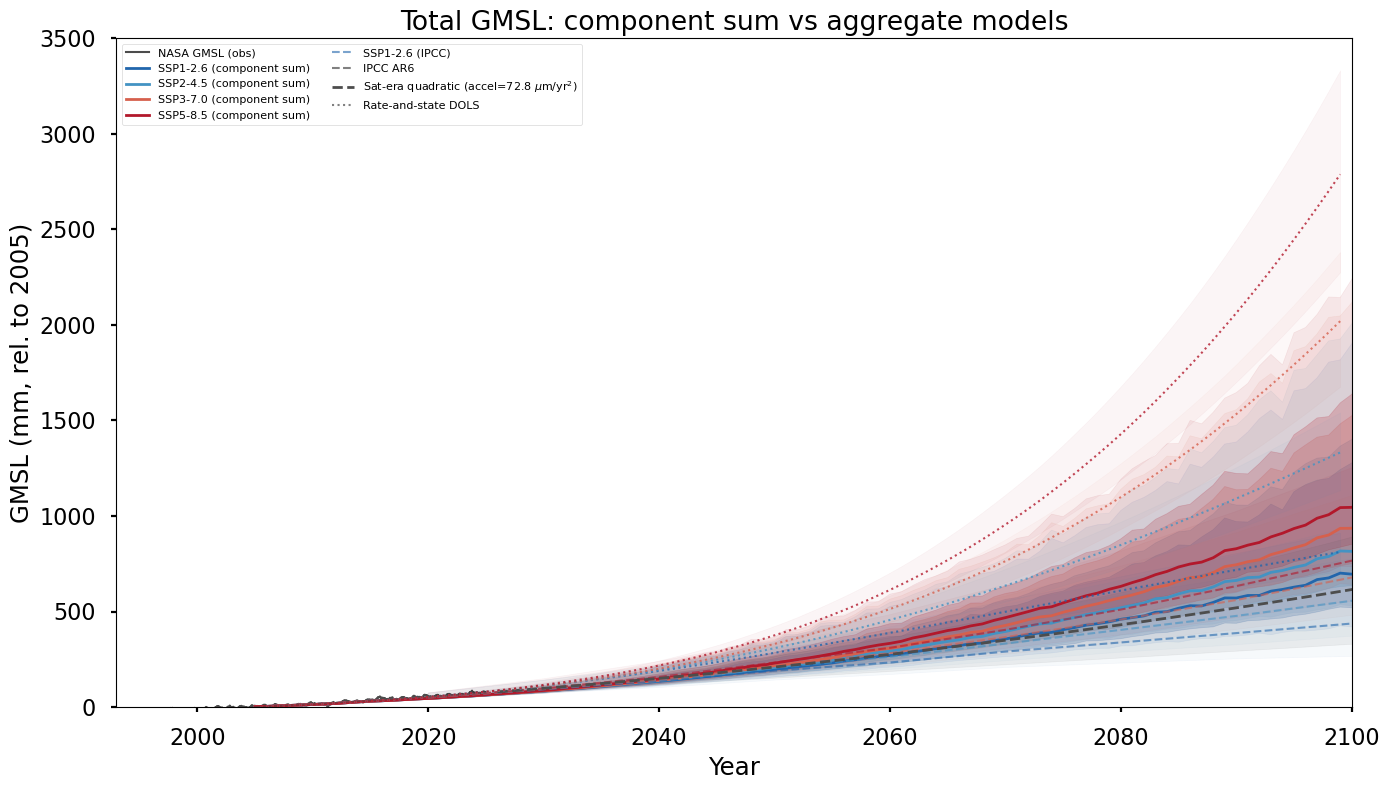

In [21]:
# ── Total GMSL projection: all SSPs + quad fit + rate-and-state ──

# ====== SWITCHES ======
SHOW_OBS        = True   # NASA GMSL observations
SHOW_QUAD       = True   # Satellite-era quadratic extrapolation
SHOW_RS         = True   # Rate-and-state DOLS
SHOW_IPCC       = True   # IPCC AR6 total projections
SHOW_COMP_SUM   = True   # Component sum
YEAR_END        = 2100   # right edge of x-axis
# ======================

proj_mask = proj_years >= 2005
yr_plot = proj_years[proj_mask]

fig, ax = plt.subplots(figsize=(14, 8))

# --- NASA GMSL observations ---
if SHOW_OBS:
    obs_mask = nasa_time >= 1993
    ax.plot(nasa_time[obs_mask], nasa_gmsl_rb[obs_mask] * M_TO_MM,
            'k-', lw=1.5, alpha=0.7, label='NASA GMSL (obs)')

# --- Component sum (per SSP) ---
if SHOW_COMP_SUM:
    for ssp in PROJ_SSPS:
        p = comp_projections[ssp]['Total_sum']
        med = p['median'][proj_mask] * M_TO_MM
        lo17 = p['p17'][proj_mask] * M_TO_MM
        hi83 = p['p83'][proj_mask] * M_TO_MM
        lo5 = p['p5'][proj_mask] * M_TO_MM
        hi95 = p['p95'][proj_mask] * M_TO_MM
        color = SSP_COLORS.get(ssp, 'gray')
        ax.plot(yr_plot, med, color=color, lw=2, label=f'{ssp} (component sum)')
        ax.fill_between(yr_plot, lo17, hi83, color=color, alpha=0.20)
        ax.fill_between(yr_plot, lo5, hi95, color=color, alpha=0.08)

# --- IPCC AR6 total ---
if SHOW_IPCC:
    for ssp in PROJ_SSPS:
        if ssp in ipcc_total:
            ie = ipcc_extract(ipcc_total[ssp])
            color = SSP_COLORS.get(ssp, 'gray')
            ax.plot(ie['years'], ie['q50'], color=color, lw=1.5, ls='--', alpha=0.6,
                    label=f'{ssp} (IPCC)' if ssp == PROJ_SSPS[0] else '')
            ax.fill_between(ie['years'], ie['q05'], ie['q95'],
                            color=color, alpha=0.04)
    ax.plot([], [], ls='--', color='0.5', lw=1.5, label='IPCC AR6')

# --- Satellite-era quadratic extrapolation ---
if SHOW_QUAD:
    sq_obs_mask = (sat_quad_time >= 2005) & (sat_quad_time <= nasa_time[-1])
    ax.plot(sat_quad_time[sq_obs_mask], sat_quad_fit_rb[sq_obs_mask] * M_TO_MM,
            '-', color='0.3', lw=1, alpha=0.6)
    sq_ext_mask = sat_quad_time >= nasa_time[-1]
    ax.plot(sat_quad_time[sq_ext_mask], sat_quad_fit_rb[sq_ext_mask] * M_TO_MM,
            '--', color='0.3', lw=2,
            label=f'Sat-era quadratic (accel={sat_quad.accel*1e6:.1f} $\\mu$m/yr$^2$)')
    ax.fill_between(sat_quad_time[sq_ext_mask],
                    sat_quad_p5[sq_ext_mask] * M_TO_MM,
                    sat_quad_p95[sq_ext_mask] * M_TO_MM,
                    color='0.3', alpha=0.08)

# --- Rate-and-state DOLS (per SSP) ---
if SHOW_RS:
    for ssp in PROJ_SSPS:
        rs_df = rs_results['scenarios'][ssp]
        rs_time = rs_df['decimal_year'].values
        mask_rs = (rs_time >= 2005) & (rs_time <= YEAR_END)
        color = SSP_COLORS.get(ssp, 'gray')
        ax.plot(rs_time[mask_rs], rs_df['gmsl'].values[mask_rs] * M_TO_MM,
                ':', color=color, lw=1.5, alpha=0.8)
        ax.fill_between(rs_time[mask_rs],
                        rs_df['gmsl_lower'].values[mask_rs] * M_TO_MM,
                        rs_df['gmsl_upper'].values[mask_rs] * M_TO_MM,
                        color=color, alpha=0.04)
    ax.plot([], [], ':', color='0.5', lw=1.5, label='Rate-and-state DOLS')

ax.set_ylim(0,3500)

ax.set_xlabel('Year')
ax.set_ylabel('GMSL (mm, rel. to 2005)')
ax.set_title('Total GMSL: component sum vs aggregate models')
ax.set_xlim(1993 if SHOW_OBS else 2005, YEAR_END)
ax.axhline(0, color='k', lw=0.5, ls='--')
ax.legend(fontsize=8, loc='upper left', ncol=2)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/component_summation_total.png', dpi=150, bbox_inches='tight')
plt.show()

  IPCC excl. AIS SSP1-2.6 at 2100: 315 [140, 536] mm (Thermosteric, Glaciers, Greenland, TWS)
  IPCC excl. AIS SSP2-4.5 at 2100: 433 [240, 675] mm (Thermosteric, Glaciers, Greenland, TWS)
  IPCC excl. AIS SSP3-7.0 at 2100: 555 [340, 812] mm (Thermosteric, Glaciers, Greenland, TWS)
  IPCC excl. AIS SSP5-8.5 at 2100: 632 [404, 930] mm (Thermosteric, Glaciers, Greenland, TWS)


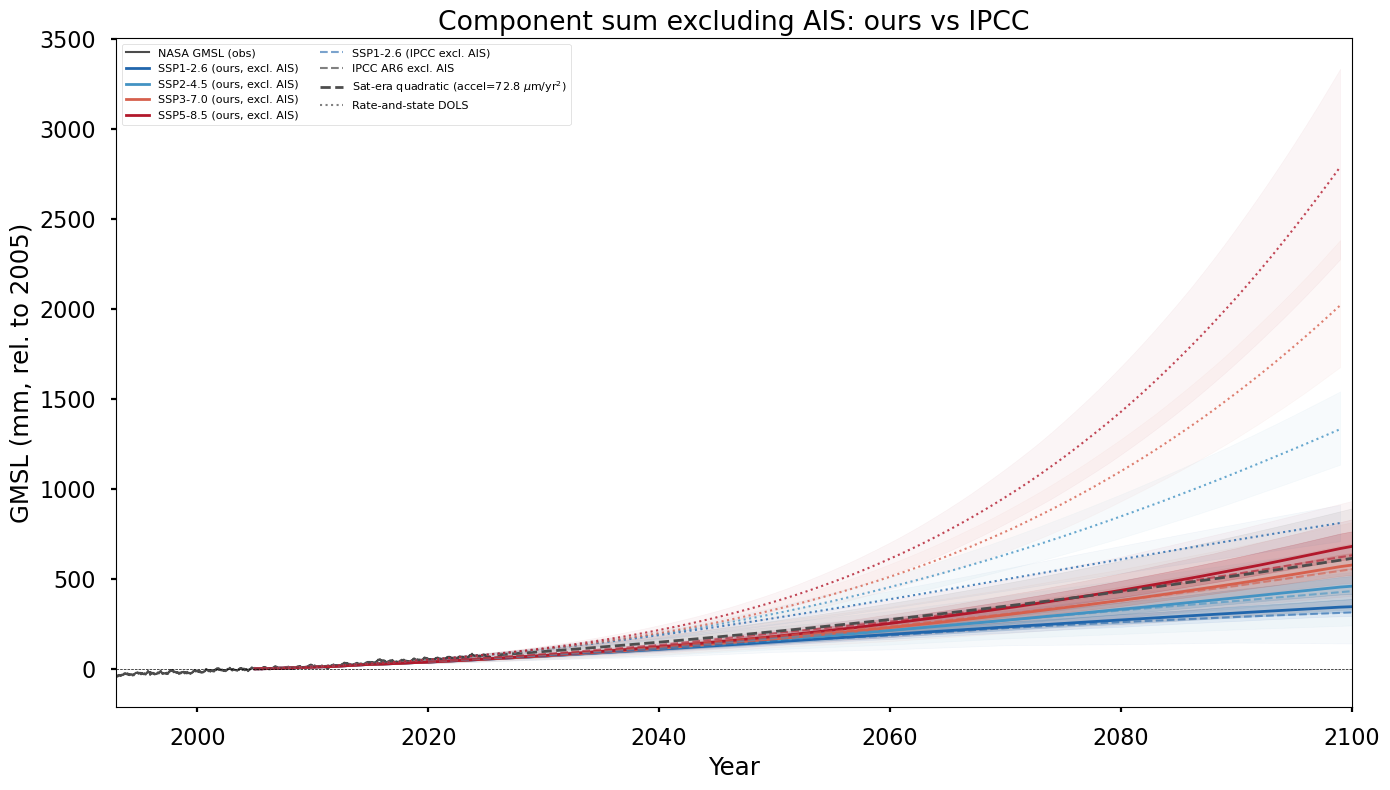

In [22]:
# ── Total GMSL excluding AIS: component-level comparison with IPCC ──
# Remove all Antarctic components (EAIS, WAIS, Peninsula) from both
# our sum and the IPCC sum for a like-for-like comparison.

# ====== SWITCHES ======
SHOW_OBS_NA     = True   # NASA GMSL observations
SHOW_QUAD_NA    = True   # Satellite-era quadratic extrapolation
SHOW_RS_NA      = True   # Rate-and-state DOLS
SHOW_IPCC_NA    = True   # IPCC component sum (excl. AIS)
SHOW_COMP_NA    = True   # Our component sum (excl. AIS)
YEAR_END_NA     = 2100   # right edge of x-axis
# ======================

ais_labels = {'EAIS', 'WAIS', 'Peninsula'}
comps_no_ais = [c for c in COMP_LABELS.values() if c not in ais_labels]

# Load IPCC components for like-for-like sum (excl. AIS)
ipcc_comp_map = {
    'oceandynamics': 'Thermosteric',
    'glaciers': 'Glaciers',
    'GIS': 'Greenland',
    'landwaterstorage': 'TWS',
}

ipcc_no_ais = {}  # {ssp: {'years': ..., 'q50': ..., 'q05': ..., 'q95': ...}}
for ssp, code in SSP_TO_CODE.items():
    comp_data = {}
    for ipcc_key, label in ipcc_comp_map.items():
        data = read_ipcc_component_nc(CONF_BASE, 'medium_confidence', code, ipcc_key)
        if data is not None:
            comp_data[label] = ipcc_extract(data)

    if not comp_data:
        continue

    # Sum on common year grid (use first component's years)
    ref_years = list(comp_data.values())[0]['years']
    q50_sum = np.zeros_like(ref_years, dtype=float)
    q05_sum = np.zeros_like(ref_years, dtype=float)
    q95_sum = np.zeros_like(ref_years, dtype=float)
    for label, ie in comp_data.items():
        q50_sum += np.interp(ref_years, ie['years'], ie['q50'])
        q05_sum += np.interp(ref_years, ie['years'], ie['q05'])
        q95_sum += np.interp(ref_years, ie['years'], ie['q95'])

    ipcc_no_ais[ssp] = {'years': ref_years, 'q50': q50_sum,
                         'q05': q05_sum, 'q95': q95_sum}

    idx_2100 = np.argmin(np.abs(ref_years - 2100))
    print(f'  IPCC excl. AIS {ssp} at 2100: {q50_sum[idx_2100]:.0f} '
          f'[{q05_sum[idx_2100]:.0f}, {q95_sum[idx_2100]:.0f}] mm '
          f'({", ".join(comp_data.keys())})')

fig, ax = plt.subplots(figsize=(14, 8))

# --- NASA GMSL observations ---
if SHOW_OBS_NA:
    obs_mask = nasa_time >= 1993
    ax.plot(nasa_time[obs_mask], nasa_gmsl_rb[obs_mask] * M_TO_MM,
            'k-', lw=1.5, alpha=0.7, label='NASA GMSL (obs)')

# --- Our component sum excluding AIS ---
if SHOW_COMP_NA:
    for ssp in PROJ_SSPS:
        total_no_ais = np.zeros_like(
            comp_projections[ssp]['Total_sum']['samples'])
        for cname in comps_no_ais:
            if cname in comp_projections[ssp]:
                total_no_ais += comp_projections[ssp][cname]['samples']

        med = np.median(total_no_ais, axis=0)[proj_mask] * M_TO_MM
        lo17 = np.percentile(total_no_ais, 17, axis=0)[proj_mask] * M_TO_MM
        hi83 = np.percentile(total_no_ais, 83, axis=0)[proj_mask] * M_TO_MM
        lo5 = np.percentile(total_no_ais, 5, axis=0)[proj_mask] * M_TO_MM
        hi95 = np.percentile(total_no_ais, 95, axis=0)[proj_mask] * M_TO_MM
        color = SSP_COLORS.get(ssp, 'gray')
        ax.plot(yr_plot, med, color=color, lw=2, label=f'{ssp} (ours, excl. AIS)')
        ax.fill_between(yr_plot, lo17, hi83, color=color, alpha=0.20)
        ax.fill_between(yr_plot, lo5, hi95, color=color, alpha=0.08)

# --- IPCC component sum excluding AIS ---
if SHOW_IPCC_NA:
    for ssp in PROJ_SSPS:
        if ssp in ipcc_no_ais:
            d = ipcc_no_ais[ssp]
            color = SSP_COLORS.get(ssp, 'gray')
            ax.plot(d['years'], d['q50'], color=color, lw=1.5, ls='--', alpha=0.6,
                    label=f'{ssp} (IPCC excl. AIS)' if ssp == PROJ_SSPS[0] else '')
            ax.fill_between(d['years'], d['q05'], d['q95'],
                            color=color, alpha=0.04)
    ax.plot([], [], ls='--', color='0.5', lw=1.5, label='IPCC AR6 excl. AIS')

# --- Satellite-era quadratic extrapolation ---
if SHOW_QUAD_NA:
    sq_obs_mask = (sat_quad_time >= 2005) & (sat_quad_time <= nasa_time[-1])
    ax.plot(sat_quad_time[sq_obs_mask], sat_quad_fit_rb[sq_obs_mask] * M_TO_MM,
            '-', color='0.3', lw=1, alpha=0.6)
    sq_ext_mask = sat_quad_time >= nasa_time[-1]
    ax.plot(sat_quad_time[sq_ext_mask], sat_quad_fit_rb[sq_ext_mask] * M_TO_MM,
            '--', color='0.3', lw=2,
            label=f'Sat-era quadratic (accel={sat_quad.accel*1e6:.1f} $\\mu$m/yr$^2$)')
    ax.fill_between(sat_quad_time[sq_ext_mask],
                    sat_quad_p5[sq_ext_mask] * M_TO_MM,
                    sat_quad_p95[sq_ext_mask] * M_TO_MM,
                    color='0.3', alpha=0.08)

# --- Rate-and-state DOLS ---
if SHOW_RS_NA:
    for ssp in PROJ_SSPS:
        rs_df = rs_results['scenarios'][ssp]
        rs_time = rs_df['decimal_year'].values
        mask_rs = (rs_time >= 2005) & (rs_time <= YEAR_END_NA)
        color = SSP_COLORS.get(ssp, 'gray')
        ax.plot(rs_time[mask_rs], rs_df['gmsl'].values[mask_rs] * M_TO_MM,
                ':', color=color, lw=1.5, alpha=0.8)
        ax.fill_between(rs_time[mask_rs],
                        rs_df['gmsl_lower'].values[mask_rs] * M_TO_MM,
                        rs_df['gmsl_upper'].values[mask_rs] * M_TO_MM,
                        color=color, alpha=0.04)
    ax.plot([], [], ':', color='0.5', lw=1.5, label='Rate-and-state DOLS')

ax.set_xlabel('Year')
ax.set_ylabel('GMSL (mm, rel. to 2005)')
ax.set_title('Component sum excluding AIS: ours vs IPCC')
ax.set_xlim(1993 if SHOW_OBS_NA else 2005, YEAR_END_NA)
ax.axhline(0, color='k', lw=0.5, ls='--')
ax.legend(fontsize=8, loc='upper left', ncol=2)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/component_summation_no_ais.png', dpi=150, bbox_inches='tight')
plt.show()

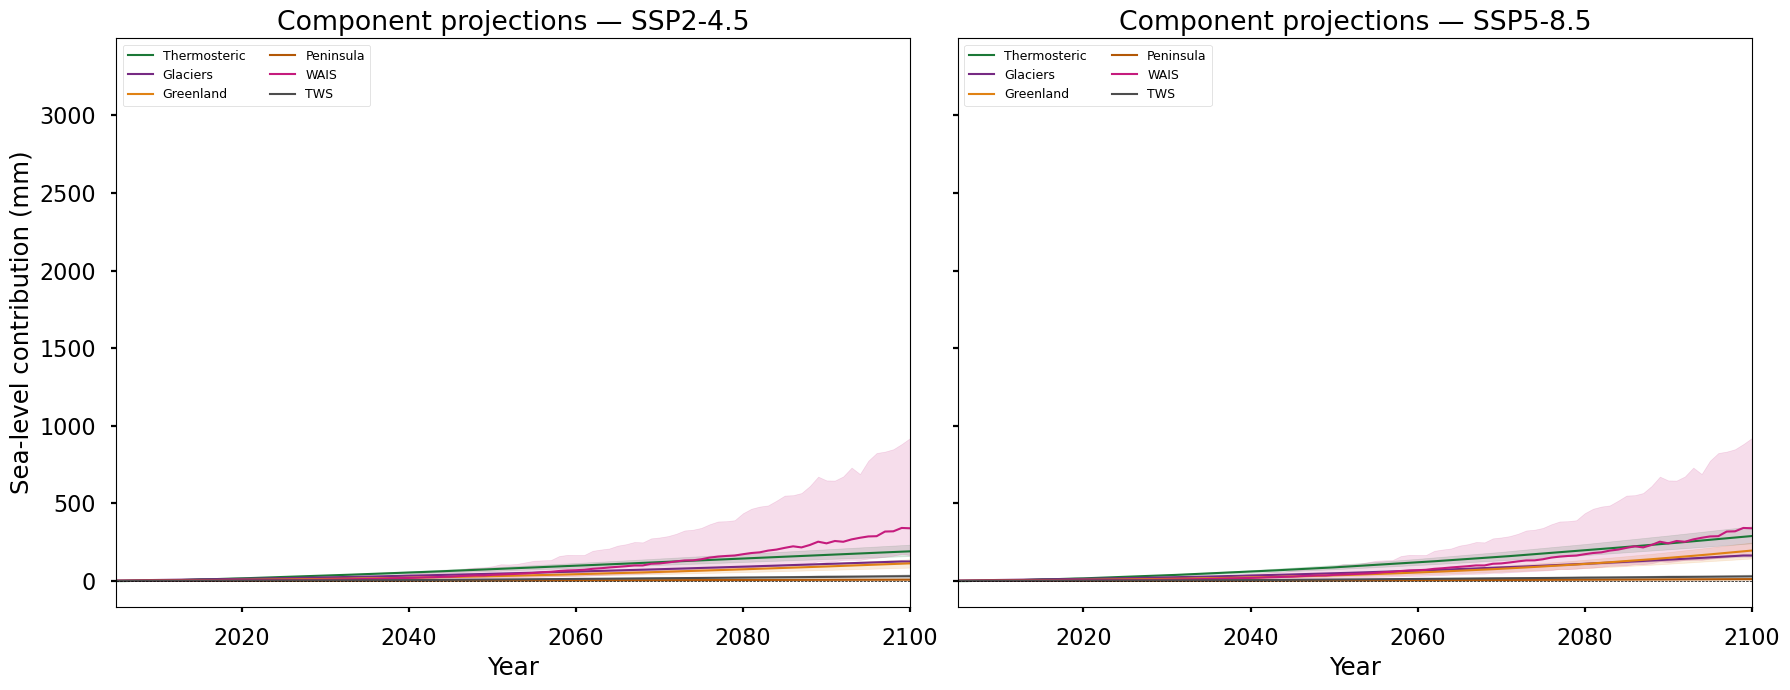

In [23]:
# ── Per-component fans for SSP2-4.5 and SSP5-8.5 ──
fig, axes = plt.subplots(1, 2, figsize=(18, 7), sharey=True)

for ax, ssp in zip(axes, ['SSP2-4.5', 'SSP5-8.5']):
    for cname in comp_order:
        if cname not in comp_projections[ssp]:
            continue
        p = comp_projections[ssp][cname]
        med = p['median'][proj_mask] * M_TO_MM
        lo = p['p17'][proj_mask] * M_TO_MM
        hi = p['p83'][proj_mask] * M_TO_MM
        color = COMP_COLORS.get(cname, 'gray')
        ax.plot(yr_plot, med, color=color, lw=1.5, label=cname)
        ax.fill_between(yr_plot, lo, hi, color=color, alpha=0.15)

    ax.set_xlabel('Year')
    ax.set_title(f'Component projections — {ssp}')
    ax.set_xlim(2005, 2100)
    ax.axhline(0, color='k', lw=0.5, ls='--')
    ax.legend(fontsize=9, loc='upper left', ncol=2)

axes[0].set_ylabel('Sea-level contribution (mm)')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/component_summation_fans.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Component Stack & Variance Decomposition

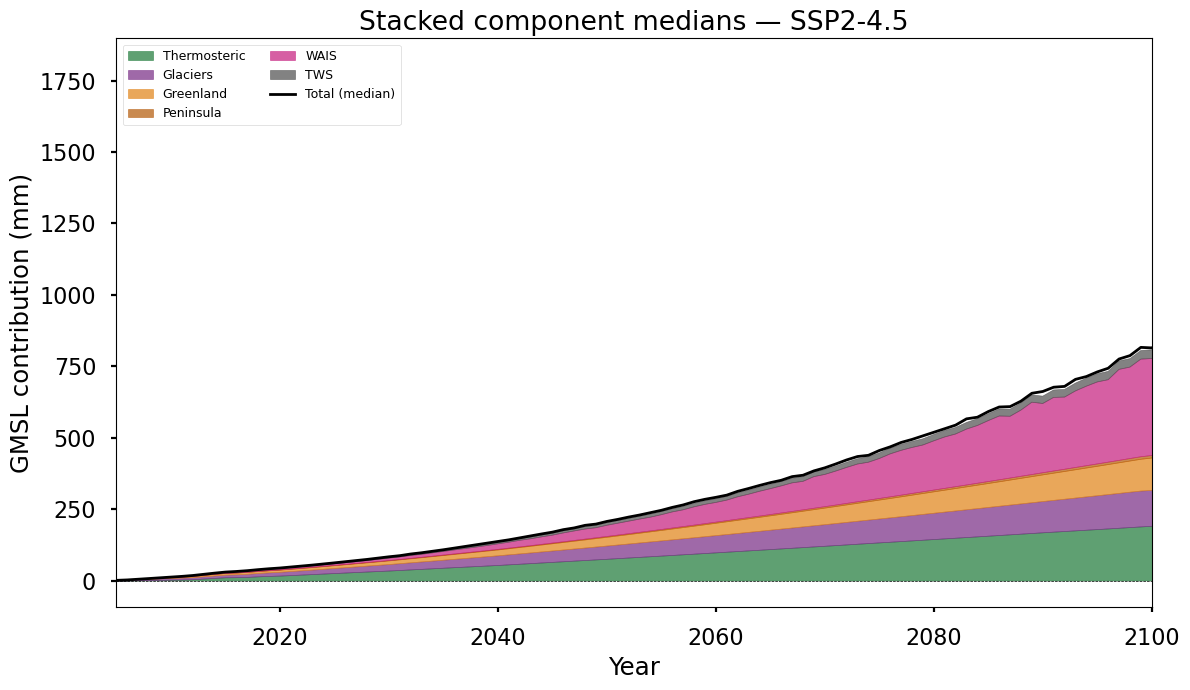

In [24]:
# ── Stacked median contributions (SSP2-4.5) ──
ssp_show = 'SSP2-4.5'
fig, ax = plt.subplots(figsize=(12, 7))

bottoms = np.zeros(proj_mask.sum())
for cname in comp_order:
    if cname not in comp_projections[ssp_show]:
        continue
    med = comp_projections[ssp_show][cname]['median'][proj_mask] * M_TO_MM
    color = COMP_COLORS.get(cname, 'gray')
    ax.fill_between(yr_plot, bottoms, bottoms + med, color=color, alpha=0.7, label=cname)
    bottoms += med

# Overlay total median
tot_med = comp_projections[ssp_show]['Total_sum']['median'][proj_mask] * M_TO_MM
ax.plot(yr_plot, tot_med, 'k-', lw=2, label='Total (median)')

ax.set_xlabel('Year')
ax.set_ylabel('GMSL contribution (mm)')
ax.set_title(f'Stacked component medians — {ssp_show}')
ax.set_xlim(2005, 2100)
ax.axhline(0, color='k', lw=0.5, ls='--')
ax.legend(loc='upper left', fontsize=9, ncol=2)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/component_summation_stacked.png', dpi=150, bbox_inches='tight')
plt.show()

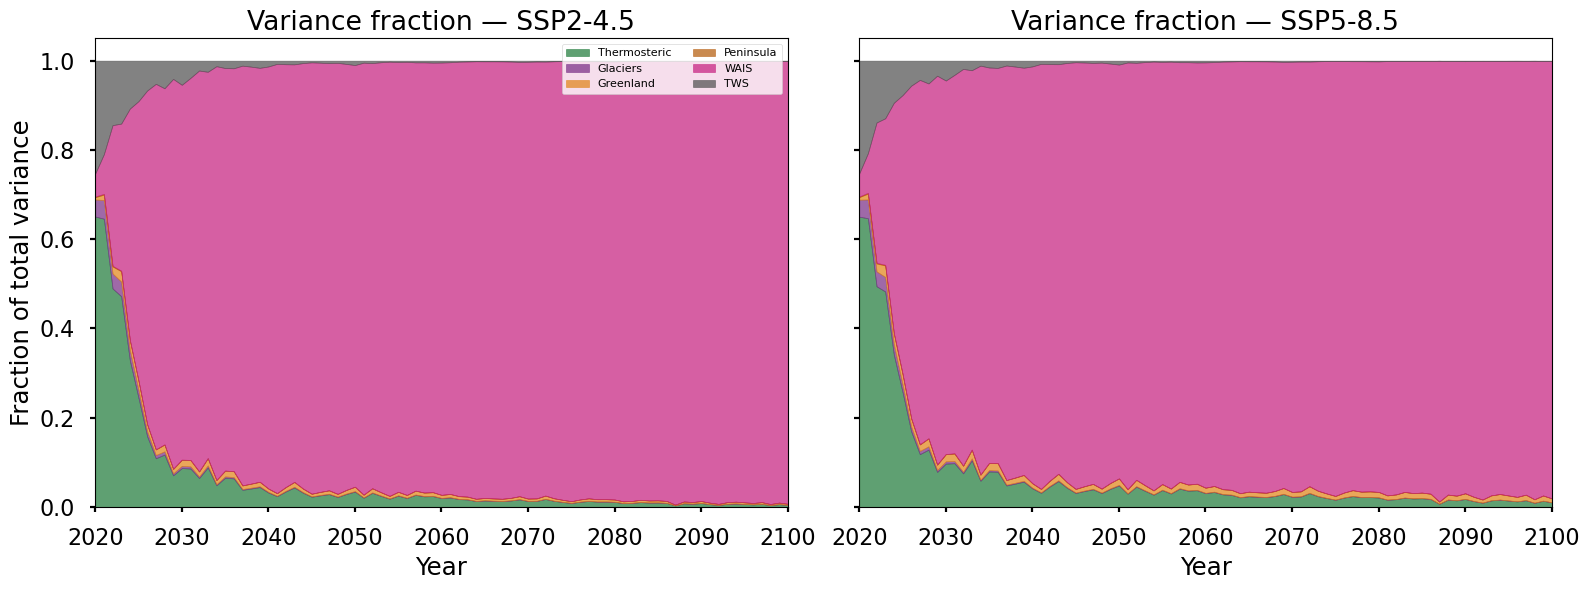

In [25]:
# ── Variance decomposition ──
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

for ax, ssp in zip(axes, ['SSP2-4.5', 'SSP5-8.5']):
    comps_available = [c for c in comp_order if c in comp_projections[ssp]]
    fracs, raw_sum = compute_variance_fractions(
        ssp, comps_available, proj_years, comp_projections,
    )
    proj_mask_var = proj_years >= 2020
    yr_var = proj_years[proj_mask_var]

    bottoms = np.zeros(proj_mask_var.sum())
    for cname in comps_available:
        f = fracs[cname][proj_mask_var]
        color = COMP_COLORS.get(cname, 'gray')
        ax.fill_between(yr_var, bottoms, bottoms + f, color=color, alpha=0.7, label=cname)
        bottoms += f

    ax.set_xlim(2020, 2100)
    ax.set_ylim(0, 1.05)
    ax.set_xlabel('Year')
    ax.set_title(f'Variance fraction — {ssp}')

axes[0].set_ylabel('Fraction of total variance')
axes[0].legend(fontsize=8, loc='upper right', ncol=2)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/component_summation_variance.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. IPCC AR6 Comparison

In [26]:
# IPCC total already loaded in cell 10 — print summary
for ssp in sorted(ipcc_total.keys()):
    data = ipcc_total[ssp]
    print(f'  {ssp}: {data["years"][0]:.0f}–{data["years"][-1]:.0f}, '
          f'{len(data["quantiles"])} quantiles')

  SSP1-2.6: 2020–2150, 107 quantiles
  SSP2-4.5: 2020–2150, 107 quantiles
  SSP3-7.0: 2020–2150, 107 quantiles
  SSP5-8.5: 2020–2150, 107 quantiles


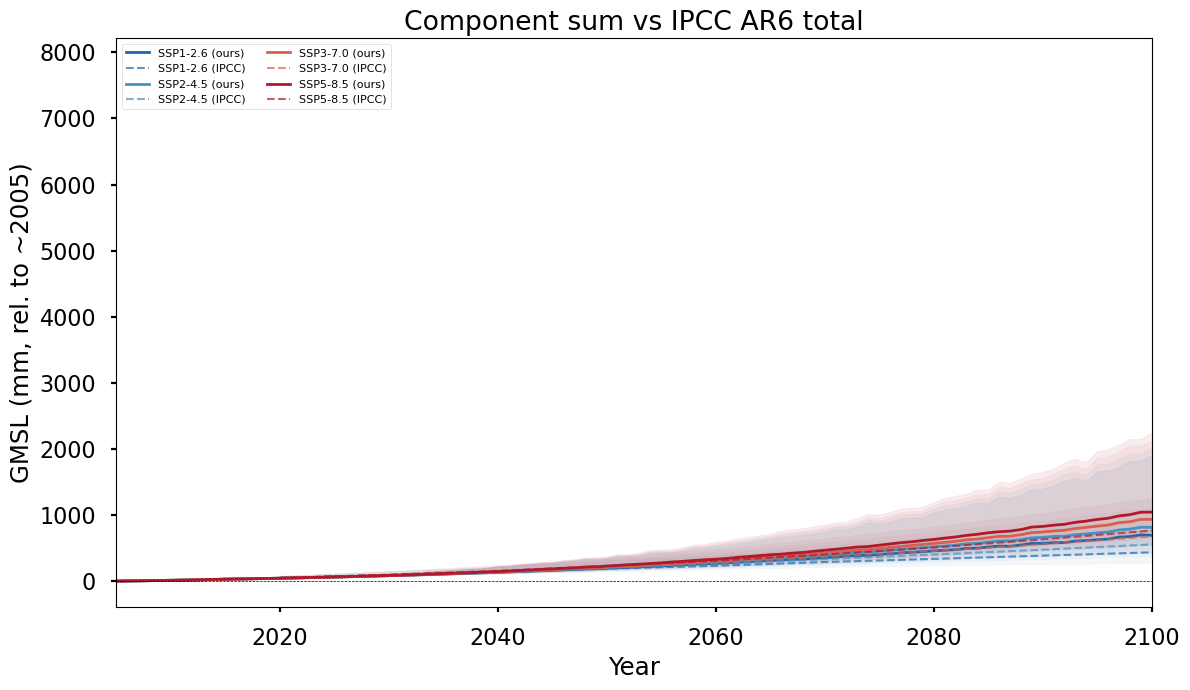

In [27]:
# ── Our total vs IPCC total ──
fig, ax = plt.subplots(figsize=(12, 7))

for ssp in PROJ_SSPS:
    color = SSP_COLORS.get(ssp, 'gray')

    # Our projection
    p = comp_projections[ssp]['Total_sum']
    med = p['median'][proj_mask] * M_TO_MM
    lo = p['p5'][proj_mask] * M_TO_MM
    hi = p['p95'][proj_mask] * M_TO_MM
    ax.plot(yr_plot, med, color=color, lw=2, label=f'{ssp} (ours)')
    ax.fill_between(yr_plot, lo, hi, color=color, alpha=0.08)

    # IPCC
    if ssp in ipcc_total:
        ipcc_d = ipcc_total[ssp]
        ie = ipcc_extract(ipcc_d)
        ax.plot(ie['years'], ie['q50'], color=color, lw=1.5, ls='--', alpha=0.7,
                label=f'{ssp} (IPCC)')
        ax.fill_between(ie['years'], ie['q05'], ie['q95'],
                         color=color, alpha=0.05, linestyle='--')

ax.set_xlabel('Year')
ax.set_ylabel('GMSL (mm, rel. to ~2005)')
ax.set_title('Component sum vs IPCC AR6 total')
ax.set_xlim(2005, 2100)
ax.axhline(0, color='k', lw=0.5, ls='--')
ax.legend(fontsize=8, loc='upper left', ncol=2)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/component_summation_vs_ipcc.png', dpi=150, bbox_inches='tight')
plt.show()

In [28]:
# ── Numerical comparison at 2100 ──
print(f'{"SSP":<12} {"Ours (median [5,95])":<30} {"IPCC (median [5,95])":<30}')
print('-' * 72)
for ssp in PROJ_SSPS:
    idx_2100 = np.argmin(np.abs(proj_years - 2100))
    s = comp_projections[ssp]['Total_sum']['samples'][:, idx_2100] * M_TO_MM
    ours_str = f'{np.median(s):.0f} [{np.percentile(s, 5):.0f}, {np.percentile(s, 95):.0f}]'

    if ssp in ipcc_total:
        ipcc_stats = get_ipcc_stats(
            {ssp: {'total': ipcc_total[ssp]}}, ssp, 'total', year=2100,
        )
        if ipcc_stats is not None:
            ipcc_str = f'{ipcc_stats[1]:.0f} [{ipcc_stats[0]:.0f}, {ipcc_stats[2]:.0f}]'
        else:
            ipcc_str = '—'
    else:
        ipcc_str = '—'

    print(f'{ssp:<12} {ours_str:<30} {ipcc_str:<30}')

SSP          Ours (median [5,95])           IPCC (median [5,95])          
------------------------------------------------------------------------
SSP1-2.6     695 [419, 1902]                437 [265, 775]                
SSP2-4.5     815 [530, 2006]                556 [371, 946]                
SSP3-7.0     936 [642, 2117]                678 [480, 1105]               
SSP5-8.5     1045 [735, 2239]               766 [555, 1252]               
